### Import de librerías


In [120]:
# Import de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import statsmodels.api as sm
import glob
import polars as pl
import timeit
from scipy.stats import skew, kurtosis

### Import de dataset

In [121]:
# path a los archivos parquet
## files = glob.glob("../dataset/.parquet")
files = glob.glob("../dataset/yellow_tripdata_2024-01.parquet")

# leer .parquet files y concatenar en un solo df 
df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

print(len(files), "files merged")
print(df.shape)

# Formato de visualización de floats en pandas
pd.set_option('display.float_format', '{:.2f}'.format)

1 files merged
(2964624, 19)


### Description

In [122]:
df.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.00,1.72,1.00,N,186,79,2,17.70,1.00,0.50,0.00,0.00,1.00,22.70,2.50,0.00
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.00,1.80,1.00,N,140,236,1,10.00,3.50,0.50,3.75,0.00,1.00,18.75,2.50,0.00
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.00,4.70,1.00,N,236,79,1,23.30,3.50,0.50,3.00,0.00,1.00,31.30,2.50,0.00
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.00,1.40,1.00,N,79,211,1,10.00,3.50,0.50,2.00,0.00,1.00,17.00,2.50,0.00
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.00,0.80,1.00,N,211,148,1,7.90,3.50,0.50,3.20,0.00,1.00,16.10,2.50,0.00
5,1,2024-01-01 00:54:08,2024-01-01 01:26:31,1.00,4.70,1.00,N,148,141,1,29.60,3.50,0.50,6.90,0.00,1.00,41.50,2.50,0.00
6,2,2024-01-01 00:49:44,2024-01-01 01:15:47,2.00,10.82,1.00,N,138,181,1,45.70,6.00,0.50,10.00,0.00,1.00,64.95,0.00,1.75
7,1,2024-01-01 00:30:40,2024-01-01 00:58:40,0.00,3.00,1.00,N,246,231,2,25.40,3.50,0.50,0.00,0.00,1.00,30.40,2.50,0.00
8,2,2024-01-01 00:26:01,2024-01-01 00:54:12,1.00,5.44,1.00,N,161,261,2,31.00,1.00,0.50,0.00,0.00,1.00,36.00,2.50,0.00
9,2,2024-01-01 00:28:08,2024-01-01 00:29:16,1.00,0.04,1.00,N,113,113,2,3.00,1.00,0.50,0.00,0.00,1.00,8.00,2.50,0.00


In [123]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,2964624.00,2964624,2964624,2824462.00,2964624.00,2824462.00,2964624.00,2964624.00,2964624.00,2964624.00,2964624.00,2964624.00,2964624.00,2964624.00,2964624.00,2964624.00,2824462.00,2824462.00
mean,1.75,2024-01-17 00:46:36.431092,2024-01-17 01:02:13.208130,1.34,3.65,2.07,166.02,165.12,1.16,18.18,1.45,0.48,3.34,0.53,0.98,26.80,2.26,0.14
min,1.00,2002-12-31 22:59:39,2002-12-31 23:05:41,0.00,0.00,1.00,1.00,1.00,0.00,-899.00,-7.50,-0.50,-80.00,-80.00,-1.00,-900.00,-2.50,-1.75
25%,2.00,2024-01-09 15:59:19.750000,2024-01-09 16:16:23,1.00,1.00,1.00,132.00,114.00,1.00,8.60,0.00,0.50,1.00,0.00,1.00,15.38,2.50,0.00
50%,2.00,2024-01-17 10:45:37.500000,2024-01-17 11:03:51.500000,1.00,1.68,1.00,162.00,162.00,1.00,12.80,1.00,0.50,2.70,0.00,1.00,20.10,2.50,0.00
75%,2.00,2024-01-24 18:23:52.250000,2024-01-24 18:40:29,1.00,3.11,1.00,234.00,234.00,1.00,20.50,2.50,0.50,4.12,0.00,1.00,28.56,2.50,0.00
max,6.00,2024-02-01 00:01:15,2024-02-02 13:56:52,9.00,312722.30,99.00,265.00,265.00,4.00,5000.00,14.25,4.00,428.00,115.92,1.00,5000.00,2.50,1.75
std,0.43,NaN,NaN,0.85,225.46,9.82,63.62,69.32,0.58,18.95,1.80,0.12,3.90,2.13,0.22,23.39,0.82,0.49


In [124]:
# print tipo de columnas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2964624 entries, 0 to 2964623
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

### Decoding Variables caterógicas

In [125]:
# decoding de variables codificadas por diccionarios 
vendor_dict = {
    1: "Creative Mobile Technologies, LLC",
    2: "Curb Mobility, LLC",
    6: "Myle Technologies Inc",
    7: "Helix"
}

ratecode_dict = {
    1: "Standard rate",
    2: "JFK",
    3: "Newark",
    4: "Nassau or Westchester",
    5: "Negotiated fare",
    6: "Group ride",
    99: "Null/unknown"
}

payment_dict = {
    0: "Flex Fare trip",
    1: "Credit card",
    2: "Cash",
    3: "No charge",
    4: "Dispute",
    5: "Unknown",
    6: "Voided trip"
}

# con diccionarios hacemos decoding 
df["VendorID"] = df["VendorID"].map(vendor_dict)
df["RatecodeID"] = df["RatecodeID"].map(ratecode_dict)
df["payment_type"] = df["payment_type"].map(payment_dict)

df = df.rename(columns={
    "VendorID": "Vendor",
    "RatecodeID": "Ratecode"
})

# convertimos a int floats que no correspondan
df["passenger_count"] = df["passenger_count"].astype('Int64')

In [126]:
# Location

# Taxi zone requiere técnicas de data enrichment. Importamos dataset de taxi_zone_lookup
taxi_zones = pd.read_csv(r"..\dataset\taxi_zone_lookup.csv")
taxi_zones.head(5)

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [127]:
df = df.merge(
    right=taxi_zones,
    left_on='PULocationID',
    right_on='LocationID',
    how='left'   
)

df = df.rename(columns={
    "Borough": "pickup_borough",
    "Zone": "pickup_zone",
    "service_zone": "pickup_service_zone"
})

df.drop(columns=["LocationID", "PULocationID"], inplace=True)

df = df.merge(
    right=taxi_zones,
    left_on='DOLocationID',
    right_on='LocationID',
    how='left'   
)

df = df.rename(columns={
    "Borough": "dropoff_borough",
    "Zone": "dropoff_zone",
    "service_zone": "dropoff_service_zone"
})

df.drop(columns=["LocationID", "DOLocationID"], inplace=True)
df.head(2)



,Vendor,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,Ratecode,store_and_fwd_flag,payment_type,fare_amount,extra,...,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone
0,"Curb Mobility, LLC",2024-01-01 00:57:55,2024-01-01 01:17:43,1,1.72,Standard rate,N,Cash,17.70,1.00,...,1.00,22.70,2.50,0.00,Manhattan,Penn Station/Madison Sq West,Yellow Zone,Manhattan,East Village,Yellow Zone
1,"Creative Mobile Technologies, LLC",2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.80,Standard rate,N,Credit card,10.00,3.50,...,1.00,18.75,2.50,0.00,Manhattan,Lenox Hill East,Yellow Zone,Manhattan,Upper East Side North,Yellow Zone


In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2964624 entries, 0 to 2964623
Data columns (total 23 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Vendor                 object        
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        Int64         
 4   trip_distance          float64       
 5   Ratecode               object        
 6   store_and_fwd_flag     object        
 7   payment_type           object        
 8   fare_amount            float64       
 9   extra                  float64       
 10  mta_tax                float64       
 11  tip_amount             float64       
 12  tolls_amount           float64       
 13  improvement_surcharge  float64       
 14  total_amount           float64       
 15  congestion_surcharge   float64       
 16  Airport_fee            float64       
 17  pickup_borough         object        
 18  pickup_zone           

In [129]:
df.head(10)


,Vendor,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,Ratecode,store_and_fwd_flag,payment_type,fare_amount,extra,...,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone
0,"Curb Mobility, LLC",2024-01-01 00:57:55,2024-01-01 01:17:43,1,1.72,Standard rate,N,Cash,17.70,1.00,...,1.00,22.70,2.50,0.00,Manhattan,Penn Station/Madison Sq West,Yellow Zone,Manhattan,East Village,Yellow Zone
1,"Creative Mobile Technologies, LLC",2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.80,Standard rate,N,Credit card,10.00,3.50,...,1.00,18.75,2.50,0.00,Manhattan,Lenox Hill East,Yellow Zone,Manhattan,Upper East Side North,Yellow Zone
2,"Creative Mobile Technologies, LLC",2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.70,Standard rate,N,Credit card,23.30,3.50,...,1.00,31.30,2.50,0.00,Manhattan,Upper East Side North,Yellow Zone,Manhattan,East Village,Yellow Zone
3,"Creative Mobile Technologies, LLC",2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.40,Standard rate,N,Credit card,10.00,3.50,...,1.00,17.00,2.50,0.00,Manhattan,East Village,Yellow Zone,Manhattan,SoHo,Yellow Zone
4,"Creative Mobile Technologies, LLC",2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.80,Standard rate,N,Credit card,7.90,3.50,...,1.00,16.10,2.50,0.00,Manhattan,SoHo,Yellow Zone,Manhattan,Lower East Side,Yellow Zone
5,"Creative Mobile Technologies, LLC",2024-01-01 00:54:08,2024-01-01 01:26:31,1,4.70,Standard rate,N,Credit card,29.60,3.50,...,1.00,41.50,2.50,0.00,Manhattan,Lower East Side,Yellow Zone,Manhattan,Lenox Hill West,Yellow Zone
6,"Curb Mobility, LLC",2024-01-01 00:49:44,2024-01-01 01:15:47,2,10.82,Standard rate,N,Credit card,45.70,6.00,...,1.00,64.95,0.00,1.75,Queens,LaGuardia Airport,Airports,Brooklyn,Park Slope,Boro Zone
7,"Creative Mobile Technologies, LLC",2024-01-01 00:30:40,2024-01-01 00:58:40,0,3.00,Standard rate,N,Cash,25.40,3.50,...,1.00,30.40,2.50,0.00,Manhattan,West Chelsea/Hudson Yards,Yellow Zone,Manhattan,TriBeCa/Civic Center,Yellow Zone
8,"Curb Mobility, LLC",2024-01-01 00:26:01,2024-01-01 00:54:12,1,5.44,Standard rate,N,Cash,31.00,1.00,...,1.00,36.00,2.50,0.00,Manhattan,Midtown Center,Yellow Zone,Manhattan,World Trade Center,Yellow Zone
9,"Curb Mobility, LLC",2024-01-01 00:28:08,2024-01-01 00:29:16,1,0.04,Standard rate,N,Cash,3.00,1.00,...,1.00,8.00,2.50,0.00,Manhattan,Greenwich Village North,Yellow Zone,Manhattan,Greenwich Village North,Yellow Zone


## Exploración


In [130]:
# Divido en variables numéricas y categóricas
num_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_vars = df.select_dtypes(include=['object', 'category']).columns.tolist()
temp_vars = df.select_dtypes(include=['datetime64[ns]']).columns.tolist()

In [131]:
print("Numerical variables:", num_vars)
print("Categorical variables:", cat_vars)
print("Temporal variables:", temp_vars) 


Numerical variables: ['passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']
Categorical variables: ['Vendor', 'Ratecode', 'store_and_fwd_flag', 'payment_type', 'pickup_borough', 'pickup_zone', 'pickup_service_zone', 'dropoff_borough', 'dropoff_zone', 'dropoff_service_zone']
Temporal variables: ['tpep_pickup_datetime', 'tpep_dropoff_datetime']


### Funciones

In [132]:
def resumen_numericas(df, cols=None, max_print=15):
    """
    Calcula métricas descriptivas para variables numéricas.
    Muestra value_counts SOLO si la variable es entera (discreta).
    """
    if cols is None:
        cols = df.select_dtypes(include=["number"]).columns

    filas = []

    for col in cols:
        serie = df[col].dropna()
        if len(serie) == 0:
            continue

        # ---- MÉTRICAS ----
        mean_ = serie.mean()
        median_ = serie.median()
        mode_ = serie.mode().iloc[0] if not serie.mode().empty else np.nan
        var_ = serie.var()
        std_ = serie.std()
        q1 = serie.quantile(0.25)
        q3 = serie.quantile(0.75)
        iqr = q3 - q1
        min_, max_ = serie.min(), serie.max()
        skew_ = skew(serie)
        curt_ = kurtosis(serie, fisher=True)

        # Outliers
        lower_iqr = q1 - 1.5 * iqr
        upper_iqr = q3 + 1.5 * iqr
        outliers_iqr = ((serie < lower_iqr) | (serie > upper_iqr)).sum()

        lower_std = mean_ - 3 * std_
        upper_std = mean_ + 3 * std_
        outliers_std = ((serie < lower_std) | (serie > upper_std)).sum()

        # ---- Agregar fila al resumen ----
        filas.append({
            "variable": col,
            "count": len(serie),
            "media": mean_,
            "mediana": median_,
            "moda": mode_,
            "varianza": var_,
            "std": std_,
            "mín": min_,
            "máx": max_,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "skewness": skew_,
            "exceso_curtosis": curt_,
            "outliers_IQR": outliers_iqr,
            "outliers_STD": outliers_std
        })

        # ---- VALUE_COUNTS SOLO PARA ENTERAS ----
        es_entera = pd.api.types.is_integer_dtype(serie) or (serie % 1 == 0).all()

        if es_entera:
            print(f"\n🔎 Distribución de valores para '{col}' (variable entera):")
            vc = serie.value_counts().sort_index()

            # si pocos valores únicos → imprimir entero
            if vc.shape[0] <= max_print:
                display(vc.to_frame("frecuencia"))
            else:
                print(f"(Mostrando top {max_print} de {vc.shape[0]} categorías únicas)")
                display(vc.head(max_print).to_frame("frecuencia"))

    # ---- devolver DataFrame resumen ----
    resumen = pd.DataFrame(filas).set_index("variable")
    return resumen


In [133]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import probplot

def plots_numerica(df, col, sample_size=None):
    """
    EDA visual univariado para una variable numérica.
    - Si sample_size es None => usa todo el dataset
    - Si sample_size es un número => usa una muestra aleatoria (recomendado para columnas grandes)
    """
    
    serie = df[col].dropna()

    if len(serie) == 0:
        print(f"{col}: no hay datos no nulos.")
        return
    
    # ================== MÉTRICAS (full data) ==================
    mean_ = serie.mean()
    median_ = serie.median()
    mode_ = serie.mode().iloc[0] if not serie.mode().empty else None

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    lower_iqr = q1 - 1.5 * iqr
    upper_iqr = q3 + 1.5 * iqr

    es_entera = pd.api.types.is_integer_dtype(serie) or (serie % 1 == 0).all()

    # ================== MUESTREO PARA GRÁFICOS ==================
    if sample_size is None or sample_size >= len(serie):
        serie_plot = serie.copy()
    else:
        serie_plot = serie.sample(sample_size, random_state=42)

    print(f"\n=== {col} ===")
    print(f"count = {len(serie)}")
    print(f"media = {mean_:.3f} | mediana = {median_:.3f} | moda = {mode_:.3f}" if mode_ is not None else
          f"media = {mean_:.3f} | mediana = {median_:.3f} | moda = None")
    print(f"Q1 = {q1:.3f} | Q3 = {q3:.3f} | IQR = {iqr:.3f}")
    print(f"Límite IQR inferior = {lower_iqr:.3f} | superior = {upper_iqr:.3f}")
    if sample_size is not None:
        print(f"graficando con n = {len(serie_plot)} (muestra)")

    # ================== FIGURA 4 EN 1 ==================
    fig, ax = plt.subplots(2, 2, figsize=(14, 10))

    # ----------- 1) HISTOGRAMA + KDE + LÍNEAS -----------
    if es_entera:
        min_v, max_v = int(serie_plot.min()), int(serie_plot.max())
        bins = np.arange(min_v - 0.5, max_v + 1.5, 1)

        sns.histplot(serie_plot, kde=False, bins=bins, ax=ax[0,0], alpha=0.35)
        sns.kdeplot(serie_plot, ax=ax[0,0], color="black", lw=1)
        ax[0,0].set_xticks(np.arange(min_v, max_v + 1, 1))
    else:
        sns.histplot(serie_plot, kde=True, bins="auto", ax=ax[0,0], alpha=0.35)

    ax[0,0].axvline(mean_, color='red', linestyle='--', lw=2, label=f"Media = {mean_:.2f}")
    ax[0,0].axvline(median_, color='blue', linestyle='-', lw=2, label=f"Mediana = {median_:.2f}")
    if mode_ is not None:
        ax[0,0].axvline(mode_, color='green', linestyle='-.', lw=2, label=f"Moda = {mode_:.2f}")

    ax[0,0].axvline(lower_iqr, color='purple', linestyle=':', lw=2, 
                    label=f"IQR inf = {lower_iqr:.2f}")
    ax[0,0].axvline(upper_iqr, color='purple', linestyle=':', lw=2, 
                    label=f"IQR sup = {upper_iqr:.2f}")

    ax[0,0].set_title(f"Histograma + KDE – {col}")
    ax[0,0].set_xlabel(col)
    ax[0,0].set_ylabel("Frecuencia")
    ax[0,0].legend()

    # ----------- 2) BOXPLOT -----------
    sns.boxplot(x=serie_plot, ax=ax[0,1])
    ax[0,1].set_title(f"Boxplot – {col}")

    # ----------- 3) ECDF -----------
    x_sorted = np.sort(serie_plot)
    y = np.arange(1, len(x_sorted)+1) / len(x_sorted)
    ax[1,0].plot(x_sorted, y, marker=".", linestyle="none")
    ax[1,0].set_title(f"ECDF – {col}")
    ax[1,0].set_xlabel(col)
    ax[1,0].set_ylabel("F(x)")

    # ----------- 4) QQ-PLOT -----------
    probplot(serie_plot, dist="norm", plot=ax[1,1])
    ax[1,1].set_title(f"QQ-plot – {col} (n={len(serie_plot)})")

    plt.tight_layout()
    plt.show()


In [134]:
import numpy as np
import pandas as pd
import math

def resumen_categoricas(df, cols=None, max_levels=20):
    """
    Calcula métricas descriptivas para variables categóricas:
    - moda, proporción de la moda, multimodalidad
    - cardinalidad
    - frecuencias mínima/máxima y rango
    - entropía de Shannon
    - % de nulos
    
    Además imprime value_counts (completo o top N).
    """
    # Si no pasan columnas, tomar object/category por defecto
    if cols is None:
        cols = df.select_dtypes(include=["object", "category"]).columns

    # Si pasan un solo string, convertirlo en lista
    if isinstance(cols, str):
        cols = [cols]

    filas = []

    for col in cols:
        serie = df[col]
        serie_no_na = serie.dropna()
        
        if len(serie) == 0:
            continue
        
        counts = serie_no_na.value_counts()
        rel = serie_no_na.value_counts(normalize=True)
        
        cardinalidad = serie_no_na.nunique()
        n_total = len(serie)
        n_notnull = len(serie_no_na)
        n_nulos = n_total - n_notnull
        pct_nulos = n_nulos / n_total * 100
        
        if cardinalidad > 0:
            moda = counts.idxmax()
            prop_moda = rel.loc[moda]
            frec_max = counts.max()
            frec_min = counts.min()
            rango_frec = frec_max - frec_min
            modas = counts[counts == frec_max].index.tolist()
            multimodal = len(modas) > 1

            p = rel.values
            entropia = -(p * np.log2(p)).sum()
            entropia_max = math.log2(cardinalidad) if cardinalidad > 1 else 0
        else:
            moda = np.nan
            prop_moda = np.nan
            rango_frec = np.nan
            multimodal = False
            entropia = np.nan
            entropia_max = np.nan
        
        filas.append({
            "variable": col,
            "count": n_total,
            "no_nulos": n_notnull,
            "%_nulos": pct_nulos,
            "cardinalidad": cardinalidad,
            "moda": moda,
            "prop_moda": prop_moda,
            "multimodal": multimodal,
            "freq_min": counts.min() if cardinalidad > 0 else np.nan,
            "freq_max": counts.max() if cardinalidad > 0 else np.nan,
            "rango_freq": rango_frec,
            "entropia": entropia,
            "entropia_max": entropia_max
        })

        # ---- value_counts para inspección ----
        print(f"\n🔎 Distribución de valores para '{col}':")
        if counts.shape[0] <= max_levels:
            display(counts.to_frame("frecuencia"))
        else:
            print(f"(Mostrando top {max_levels} de {counts.shape[0]} categorías únicas)")
            display(counts.head(max_levels).to_frame("frecuencia"))
    
    resumen = pd.DataFrame(filas).set_index("variable")
    return resumen


In [169]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plots_categorica(
    df, col,
    max_levels=15,
    normalize=False,
    sort_by="freq",
    use_others=True
):
    """
    Plot univariado para variables categóricas.
    Incluye:
      - Barplot absoluto o proporcional
      - Pie chart
      - Agrupación opcional en 'Otros'
      - Orden configurable

    Parámetros:
    - col: nombre de la columna
    - max_levels: máximo de categorías a mostrar (si use_others=True)
    - normalize: False=frecuencia absoluta, True=proporciones
    - sort_by: 'freq' o 'category'
    - use_others: si True agrupa categorías pequeñas en 'Otros'
    """
    serie = df[col].dropna().astype("object")

    if len(serie) == 0:
        print(f"{col}: no hay datos no nulos.")
        return

    counts = serie.value_counts()

    # =========================================================
    # OPCIÓN: agrupar en 'Otros' o no
    # =========================================================
    if use_others and len(counts) > max_levels:
        top = counts.head(max_levels - 1)
        otros = counts.iloc[max_levels - 1:].sum()
        counts_plot = pd.concat([top, pd.Series({"Otros": otros})])
    else:
        counts_plot = counts.copy()

    # =========================================================
    # Normalizar o no
    # =========================================================
    if normalize:
        values_plot = counts_plot / counts_plot.sum()
        ylabel = "Proporción"
    else:
        values_plot = counts_plot
        ylabel = "Frecuencia"

    # =========================================================
    # Orden
    # =========================================================
    if sort_by == "category":
        # Intentar orden numérico si se puede
        def try_float(x):
            try:
                return float(x)
            except:
                return np.nan

        numeric_vals = pd.Series([try_float(x) for x in values_plot.index], index=values_plot.index)

        if numeric_vals.notna().mean() > 0.8:  # si 80% son numéricos, orden natural
            values_plot = values_plot.iloc[np.argsort(numeric_vals.values)]
        else:
            values_plot = values_plot.sort_index()
    else:
        values_plot = values_plot.sort_values(ascending=False)

    # =========================================================
    # 1) BARPLOT
    # =========================================================
    plt.figure(figsize=(8, 4 + 0.25*len(values_plot)))
    sns.barplot(x=values_plot.values, y=values_plot.index, orient="h")
    plt.title(f"Distribución categórica – {col} ({'%' if normalize else 'abs'})")
    plt.xlabel(ylabel)
    plt.ylabel(col)

    # Añadir valores al costado
    for i, v in enumerate(values_plot.values):
        if normalize:
            plt.text(v, i, f" {v*100:.1f}%", va="center")
        else:
            plt.text(v, i, f" {int(v)}", va="center")

    plt.tight_layout()
    plt.show()

    # =========================================================
    # 2) PIE CHART (siempre en %)
    # =========================================================
    plt.figure(figsize=(7, 7))
    plt.pie(
        counts_plot.values,
        labels=counts_plot.index,
        autopct="%1.1f%%",
        startangle=90,
        counterclock=False
    )
    plt.title(f"Gráfico de torta – {col}")
    plt.tight_layout()
    plt.show()


### Passenger_count

In [136]:
resumen_numericas(df, cols=['passenger_count'])


🔎 Distribución de valores para 'passenger_count' (variable entera):


,frecuencia
passenger_count,
0,31465
1,2188739
2,405103
3,91262
4,51974
5,33506
6,22353
7,8
8,51


,count,media,mediana,moda,varianza,std,mín,máx,Q1,Q3,IQR,skewness,exceso_curtosis,outliers_IQR,outliers_STD
variable,,,,,,,,,,,,,,,
passenger_count,2824462,1.34,1.00,1,0.72,0.85,0,9,1.00,1.00,0.00,3.04,10.67,635723,107893



=== passenger_count ===
count = 2824462
media = 1.339 | mediana = 1.000 | moda = 1.000
Q1 = 1.000 | Q3 = 1.000 | IQR = 0.000
Límite IQR inferior = 1.000 | superior = 1.000


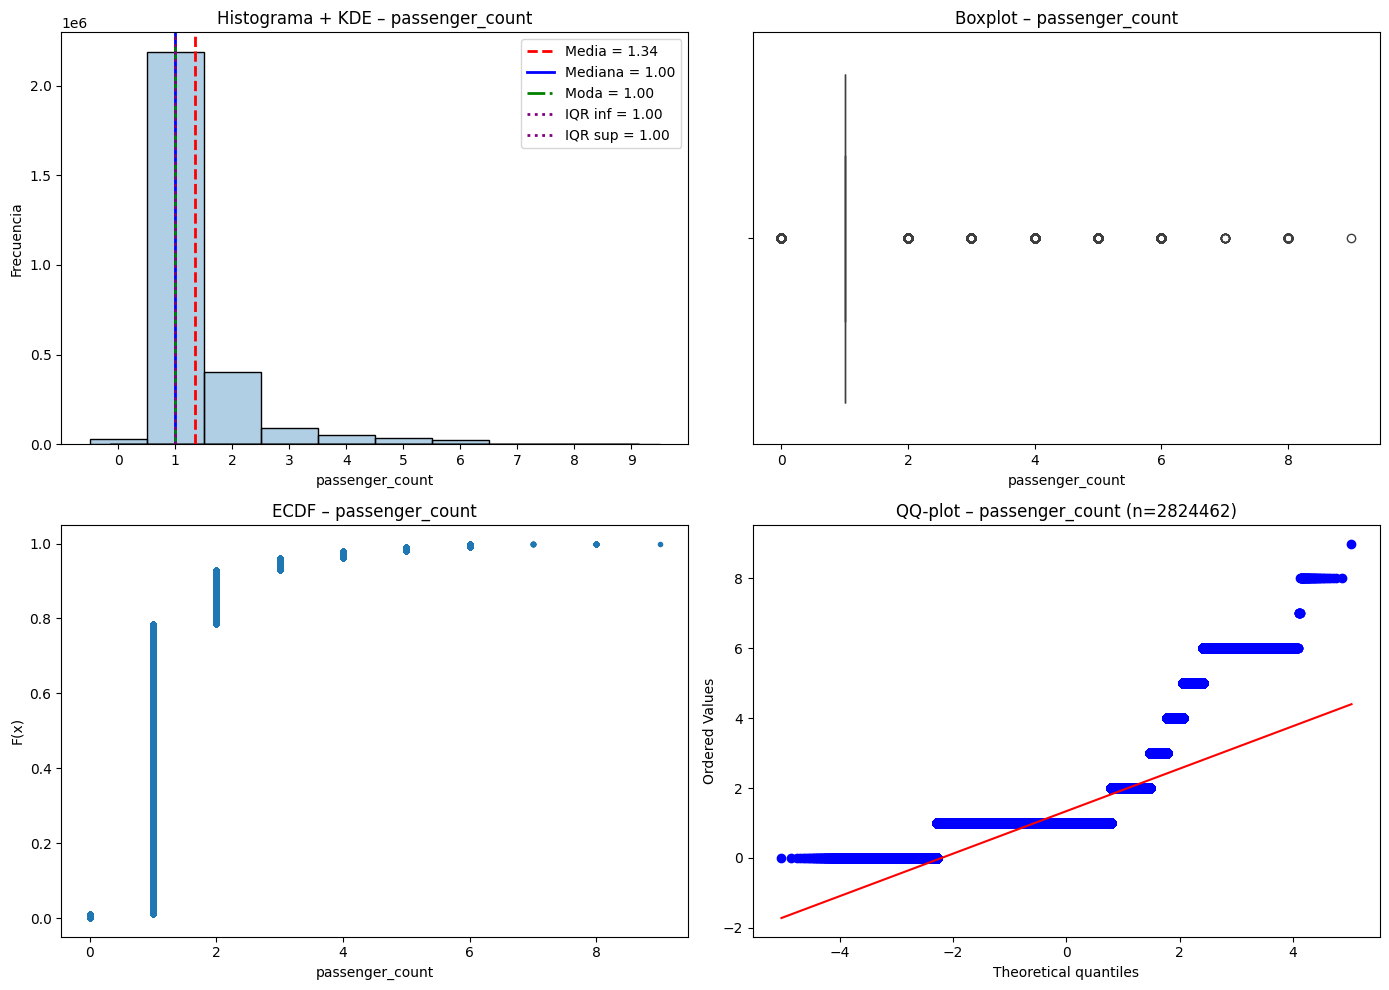

In [137]:
plots_numerica(df, col="passenger_count")

In [138]:
print("Valores originales de passenger_count:")
print(df['passenger_count'].value_counts().sort_index())

#df = df[df['passenger_count'].between(1, 4)]

# Verificación post-limpieza
#print("\nValores luego de limpieza:")
#print(df["passenger_count"].value_counts().sort_index())

df["passenger_count_clean"] = df["passenger_count"]

df.loc[
    (df["passenger_count_clean"] == 0) | 
    (df["passenger_count_clean"] > 4),
    "passenger_count_clean"
] = np.nan
print(df["passenger_count_clean"].value_counts().sort_index())

Valores originales de passenger_count:
passenger_count
0      31465
1    2188739
2     405103
3      91262
4      51974
5      33506
6      22353
7          8
8         51
9          1
Name: count, dtype: Int64
passenger_count_clean
1    2188739
2     405103
3      91262
4      51974
Name: count, dtype: Int64


In [139]:
resumen_numericas(df, cols=['passenger_count_clean'])


🔎 Distribución de valores para 'passenger_count_clean' (variable entera):


,frecuencia
passenger_count_clean,
1,2188739
2,405103
3,91262
4,51974


,count,media,mediana,moda,varianza,std,mín,máx,Q1,Q3,IQR,skewness,exceso_curtosis,outliers_IQR,outliers_STD
variable,,,,,,,,,,,,,,,
passenger_count_clean,2737078,1.27,1.00,1,0.38,0.62,1,4,1.00,1.00,0.00,2.57,6.74,548339,51974



=== passenger_count_clean ===
count = 2737078
media = 1.272 | mediana = 1.000 | moda = 1.000
Q1 = 1.000 | Q3 = 1.000 | IQR = 0.000
Límite IQR inferior = 1.000 | superior = 1.000


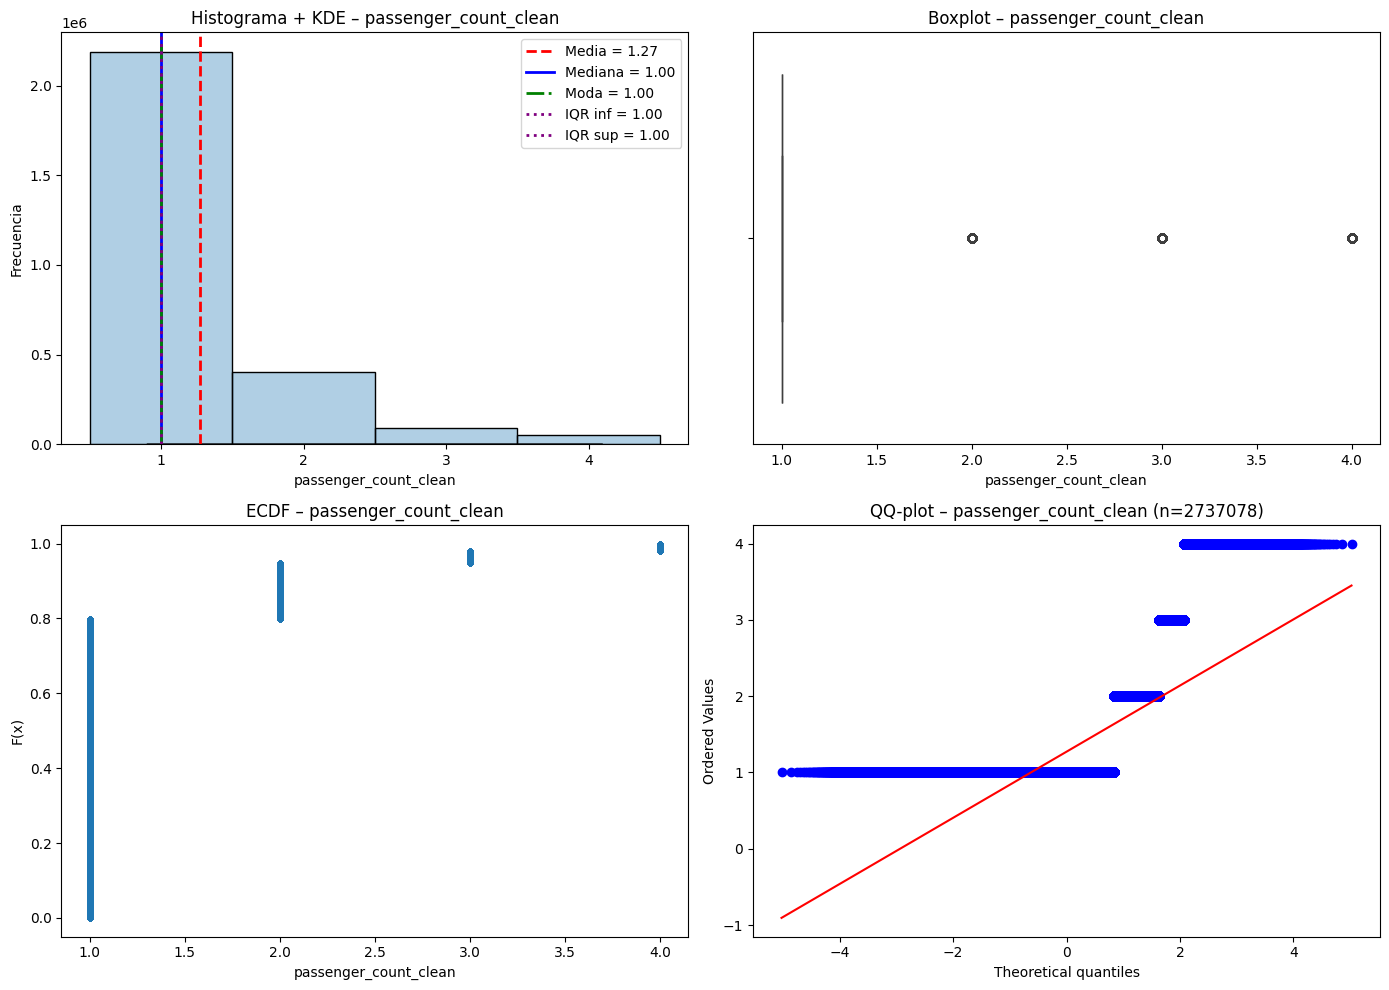

In [140]:

plots_numerica(df, col="passenger_count_clean")

Observaciones passenger_count:

- Mayormente los viajes se realizan con un único pasajero
- Hay valores no válidos: 0, 5, 6, 7, 8 -> llevar a Nan o eliminar según caso de aplicación
- No hay distribución normal



### trip_distance

In [141]:
resumen_numericas(df, cols=['trip_distance'])

,count,media,mediana,moda,varianza,std,mín,máx,Q1,Q3,IQR,skewness,exceso_curtosis,outliers_IQR,outliers_STD
variable,,,,,,,,,,,,,,,
trip_distance,2964624,3.65,1.68,0.00,50833.37,225.46,0.00,312722.30,1.00,3.11,2.11,1001.89,1281272.11,382745,25



=== trip_distance ===
count = 2964624
media = 3.652 | mediana = 1.680 | moda = 0.000
Q1 = 1.000 | Q3 = 3.110 | IQR = 2.110
Límite IQR inferior = -2.165 | superior = 6.275
graficando con n = 100000 (muestra)


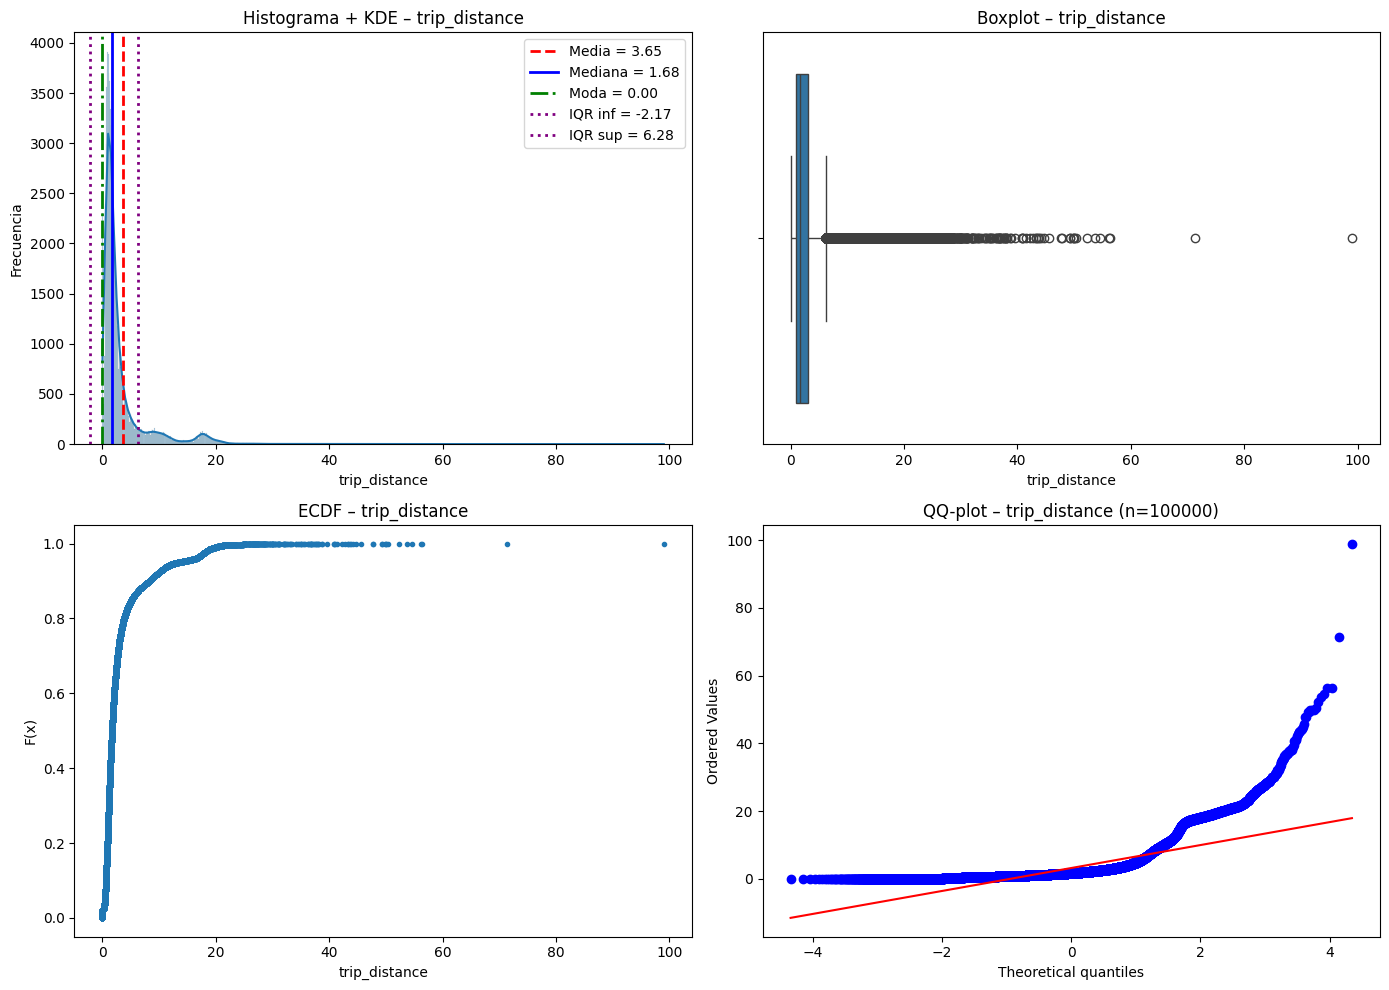

In [142]:
plots_numerica(df, col="trip_distance", sample_size=100000)

In [143]:
# 1) Bin real ordenado por cuantiles
df["trip_distance_bin"] = pd.qcut(
    df["trip_distance"],
    q=10,
    duplicates="drop",
    precision=4
)

# 2) Forzar orden explícito en el dtype category
df["trip_distance_bin"] = df["trip_distance_bin"].astype(
    pd.api.types.CategoricalDtype(
        categories=df["trip_distance_bin"].cat.categories,
        ordered=True
    )
)

# 3) Mostrar bien ordenado
df["trip_distance_bin"].value_counts().sort_index()


trip_distance_bin
(-0.0001, 0.6]      296747
(0.6, 0.88]         305303
(0.88, 1.1]         298729
(1.1, 1.37]         287564
(1.37, 1.68]        297802
(1.68, 2.07]        294044
(2.07, 2.66]        296412
(2.66, 3.84]        296292
(3.84, 8.42]        295493
(8.42, 312722.3]    296238
Name: count, dtype: int64

In [144]:
q1 = df["trip_distance"].quantile(0.25)
q3 = df["trip_distance"].quantile(0.75)
iqr = q3 - q1

upper_iqr = q3 + 6 * iqr
df_trip_distance_clean = df.copy()  

df_trip_distance_clean = df[df["trip_distance"] <= upper_iqr]
print("Máximo trip_distance luego de limpieza:", df_trip_distance_clean["trip_distance"].max())

Máximo trip_distance luego de limpieza: 15.77



=== trip_distance ===
count = 2835916
media = 2.498 | mediana = 1.600 | moda = 0.000
Q1 = 0.960 | Q3 = 2.800 | IQR = 1.840
Límite IQR inferior = -1.800 | superior = 5.560
graficando con n = 120000 (muestra)


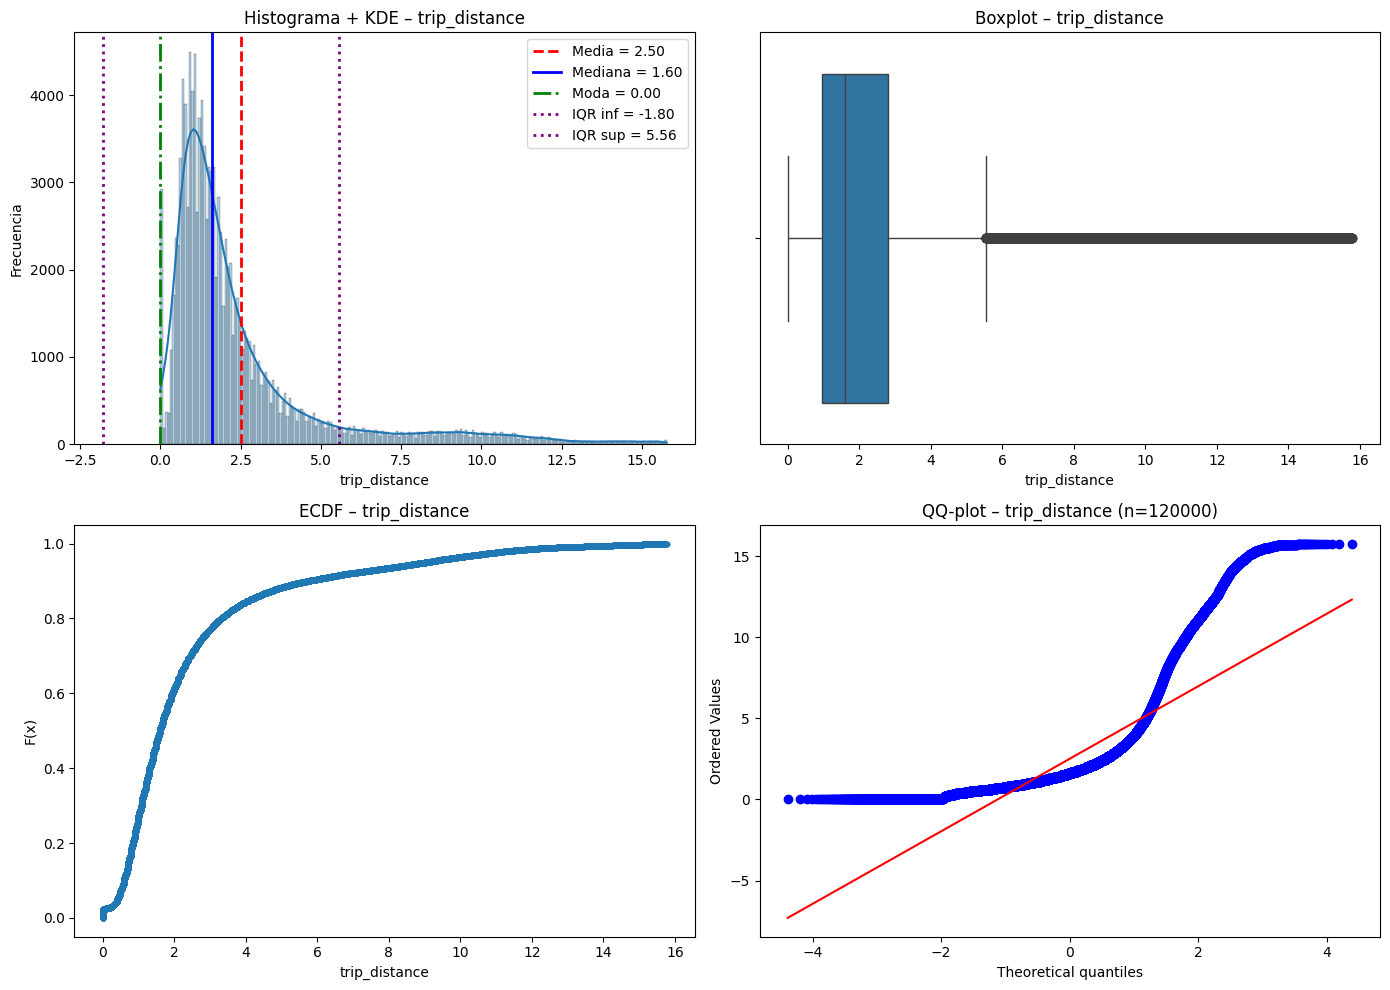

In [145]:
plots_numerica(df_trip_distance_clean, col="trip_distance", sample_size=120000)

In [146]:
# Viajes con distancia <= 0 
print("Cantidad de Viajes con distancia <= 0 :", (df["trip_distance"] <= 0).sum())
print("% de Viajes con distancia <= 0 :",((df["trip_distance"] <= 0).sum() / len(df)) * 100)
print("Viajes con distancia 0: ", df[df["trip_distance"] <= 0])

Cantidad de Viajes con distancia <= 0 : 60371
% de Viajes con distancia <= 0 : 2.0363796555650904
Viajes con distancia 0:                                      Vendor tpep_pickup_datetime  \
17                      Curb Mobility, LLC  2024-01-01 00:52:09   
23       Creative Mobile Technologies, LLC  2024-01-01 00:14:29   
111      Creative Mobile Technologies, LLC  2024-01-01 00:58:50   
198      Creative Mobile Technologies, LLC  2024-01-01 00:15:16   
199      Creative Mobile Technologies, LLC  2024-01-01 00:39:34   
...                                    ...                  ...   
2964528  Creative Mobile Technologies, LLC  2024-01-31 22:24:07   
2964535  Creative Mobile Technologies, LLC  2024-01-31 22:23:49   
2964540  Creative Mobile Technologies, LLC  2024-01-31 22:09:21   
2964550  Creative Mobile Technologies, LLC  2024-01-31 22:18:18   
2964561  Creative Mobile Technologies, LLC  2024-01-31 22:22:49   

        tpep_dropoff_datetime  passenger_count  trip_distance       Rate

                 count  media  mediana  moda  varianza  std  mín   máx   Q1  \
variable                                                                      
trip_distance  2775545   2.55     1.63  0.90      6.96 2.64 0.01 15.77 1.00   

                Q3  IQR  skewness  exceso_curtosis  outliers_IQR  outliers_STD  
variable                                                                        
trip_distance 2.84 1.84      2.35             5.68        289966         83279  

=== trip_distance ===
count = 2775545
media = 2.553 | mediana = 1.630 | moda = 0.900
Q1 = 1.000 | Q3 = 2.840 | IQR = 1.840
Límite IQR inferior = -1.760 | superior = 5.600
graficando con n = 120000 (muestra)


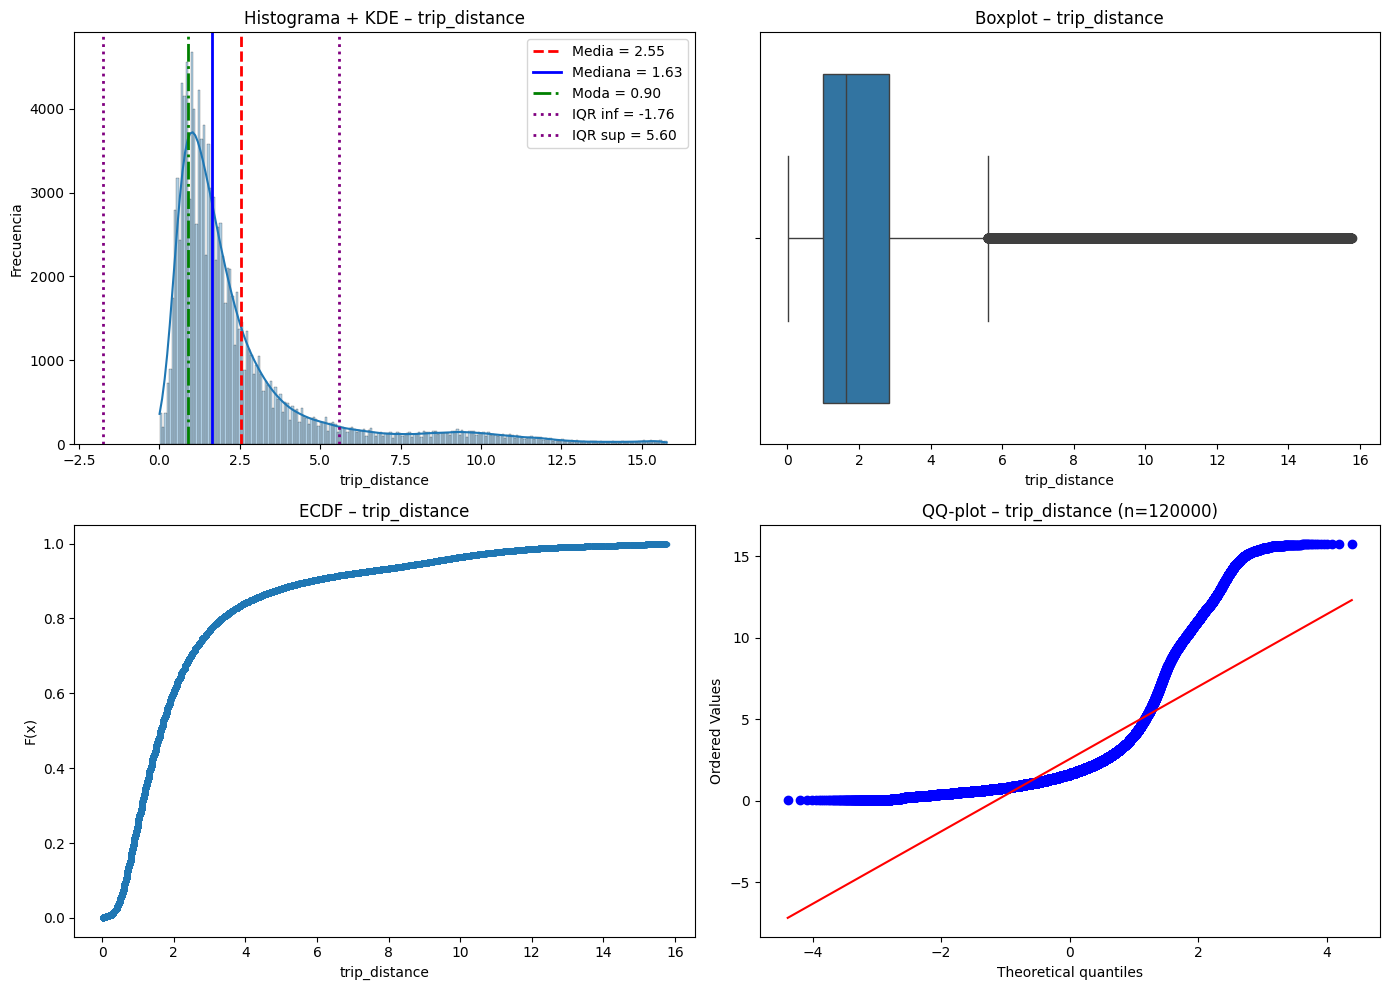

In [147]:
df_trip_distance_clean = df_trip_distance_clean[df_trip_distance_clean["trip_distance"] > 0]
print(resumen_numericas(df_trip_distance_clean, cols=["trip_distance"]))
plots_numerica(df_trip_distance_clean, col="trip_distance", sample_size=120000)

Conclusiones: 

Se debieron aplicar dos correcciones: 
1. ** Eliminación de valores no válidos (<=0)** -> nota: la mayoría igualmente tiene fare_amount
2. ** Remoción de outliers extremos en la derecha ** -> nota: Existían valores de distancia inusualmente altos (cientos de km) que no son representativos de trayectos urbanos

Post limpieza:
1. La distribución sigue siendo asimétrica hacia la derecha
2. Las métricas descriptivas (media, mediana, cuartiles) se vuelven más estables.
3. Es recomendable analizar la variable **discretizada en bins**


### fare_amount

In [148]:
resumen_numericas(df,["fare_amount"])

,count,media,mediana,moda,varianza,std,mín,máx,Q1,Q3,IQR,skewness,exceso_curtosis,outliers_IQR,outliers_STD
variable,,,,,,,,,,,,,,,
fare_amount,2964624,18.18,12.80,8.60,359.09,18.95,-899.00,5000.00,8.60,20.50,11.90,18.15,3653.46,318801,35970


In [149]:
df_fare_amount_clean = df.copy()

print("Cant. de valores de fare_amount <= 0 :", (df["fare_amount"] <= 0).sum())
df_fare_amount_clean = df_fare_amount_clean[df_fare_amount_clean["fare_amount"] > 0]
(resumen_numericas(df_fare_amount_clean, cols=["fare_amount"]))

Cant. de valores de fare_amount <= 0 : 38341


,count,media,mediana,moda,varianza,std,mín,máx,Q1,Q3,IQR,skewness,exceso_curtosis,outliers_IQR,outliers_STD
variable,,,,,,,,,,,,,,,
fare_amount,2926283,18.66,12.80,8.60,336.42,18.34,0.01,5000.00,8.60,20.50,11.90,20.82,4201.02,297368,32577



=== fare_amount ===
count = 2964624
media = 18.175 | mediana = 12.800 | moda = 8.600
Q1 = 8.600 | Q3 = 20.500 | IQR = 11.900
Límite IQR inferior = -9.250 | superior = 38.350
graficando con n = 120000 (muestra)


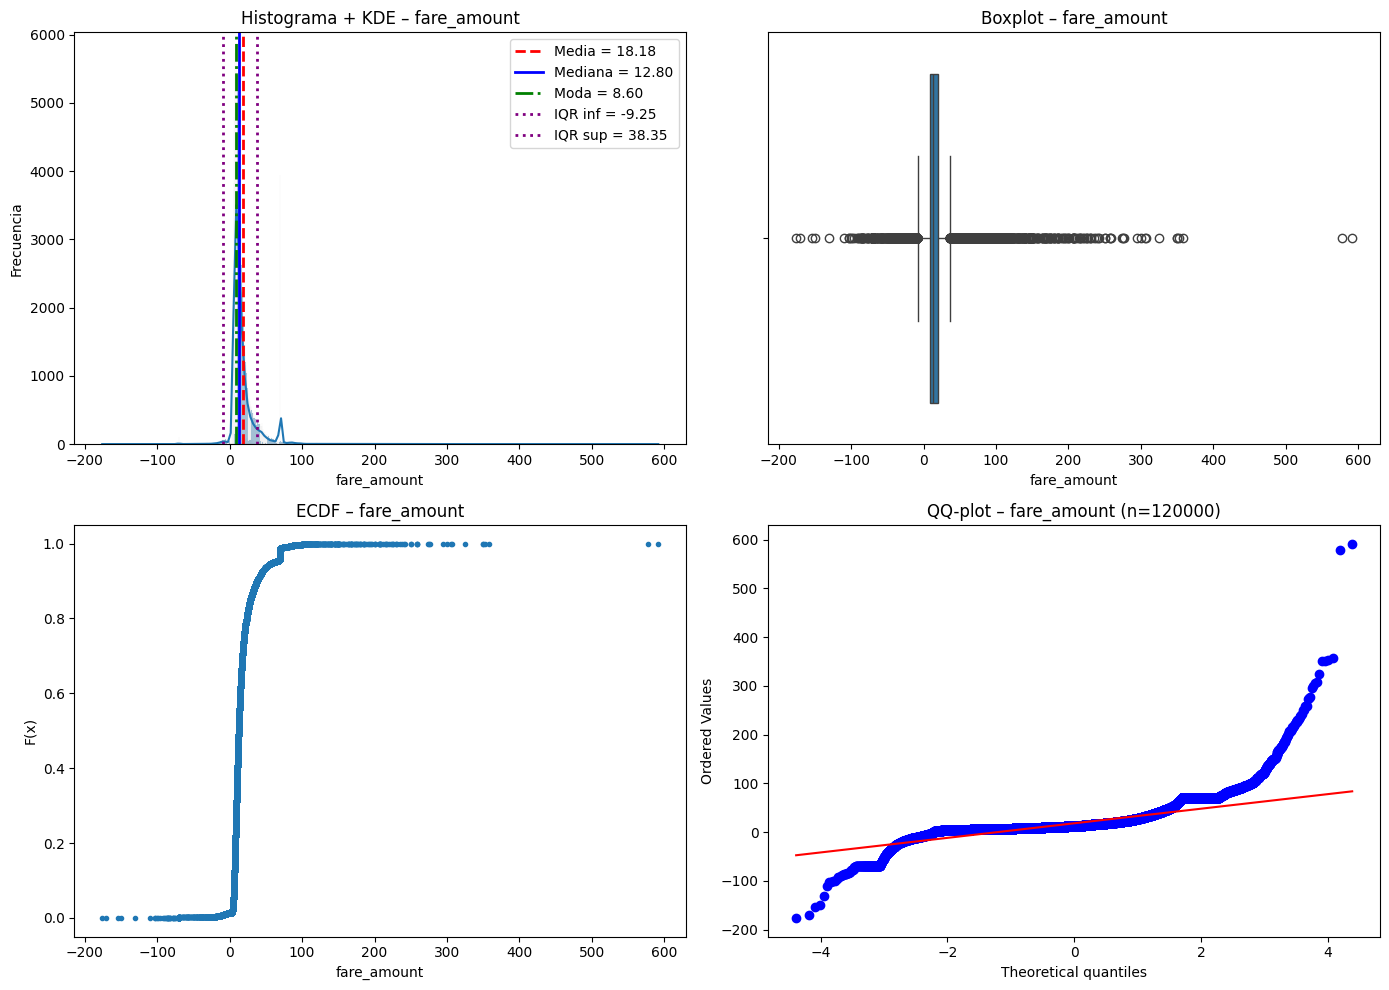

In [150]:
plots_numerica(df, col="fare_amount", sample_size=120000)


=== fare_amount ===
count = 2926283
media = 18.657 | mediana = 12.800 | moda = 8.600
Q1 = 8.600 | Q3 = 20.500 | IQR = 11.900
Límite IQR inferior = -9.250 | superior = 38.350
graficando con n = 120000 (muestra)


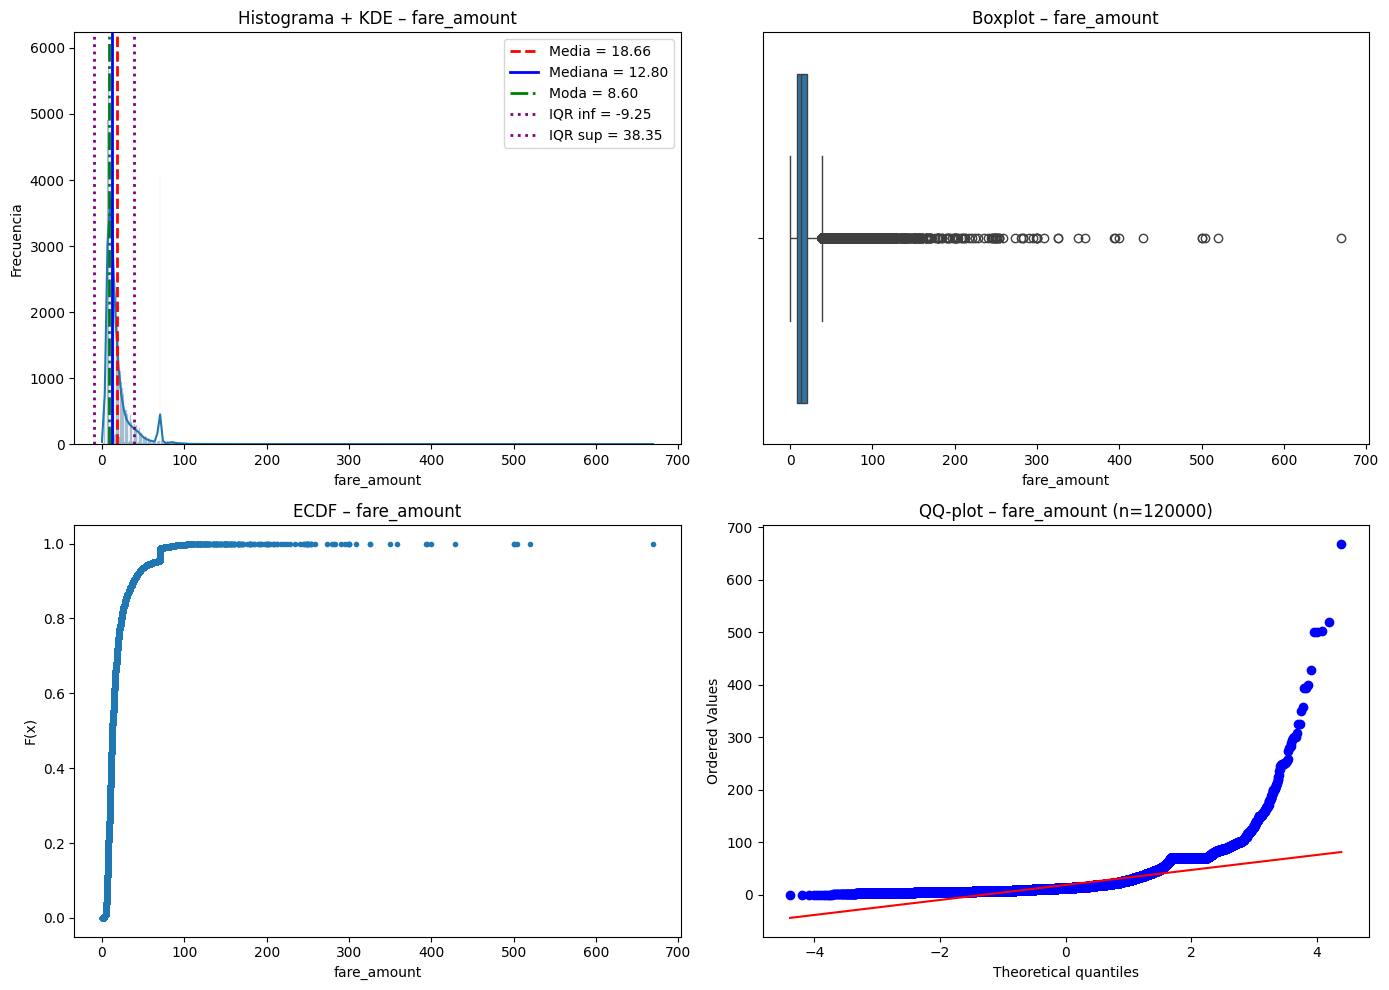

In [151]:
plots_numerica(df_fare_amount_clean, col="fare_amount", sample_size=120000)

In [152]:
q1 = df["fare_amount"].quantile(0.25)
q3 = df["fare_amount"].quantile(0.75)
iqr = q3 - q1

upper_iqr = q3 + 6 * iqr

df_fare_amount_clean = df_fare_amount_clean[df_fare_amount_clean["fare_amount"] <= upper_iqr]
print("Máximo fare_amount luego de limpieza:", df_fare_amount_clean["fare_amount"].max())

Máximo fare_amount luego de limpieza: 91.9



=== fare_amount ===
count = 2913379
media = 18.158 | mediana = 12.800 | moda = 8.600
Q1 = 8.600 | Q3 = 20.500 | IQR = 11.900
Límite IQR inferior = -9.250 | superior = 38.350
graficando con n = 120000 (muestra)


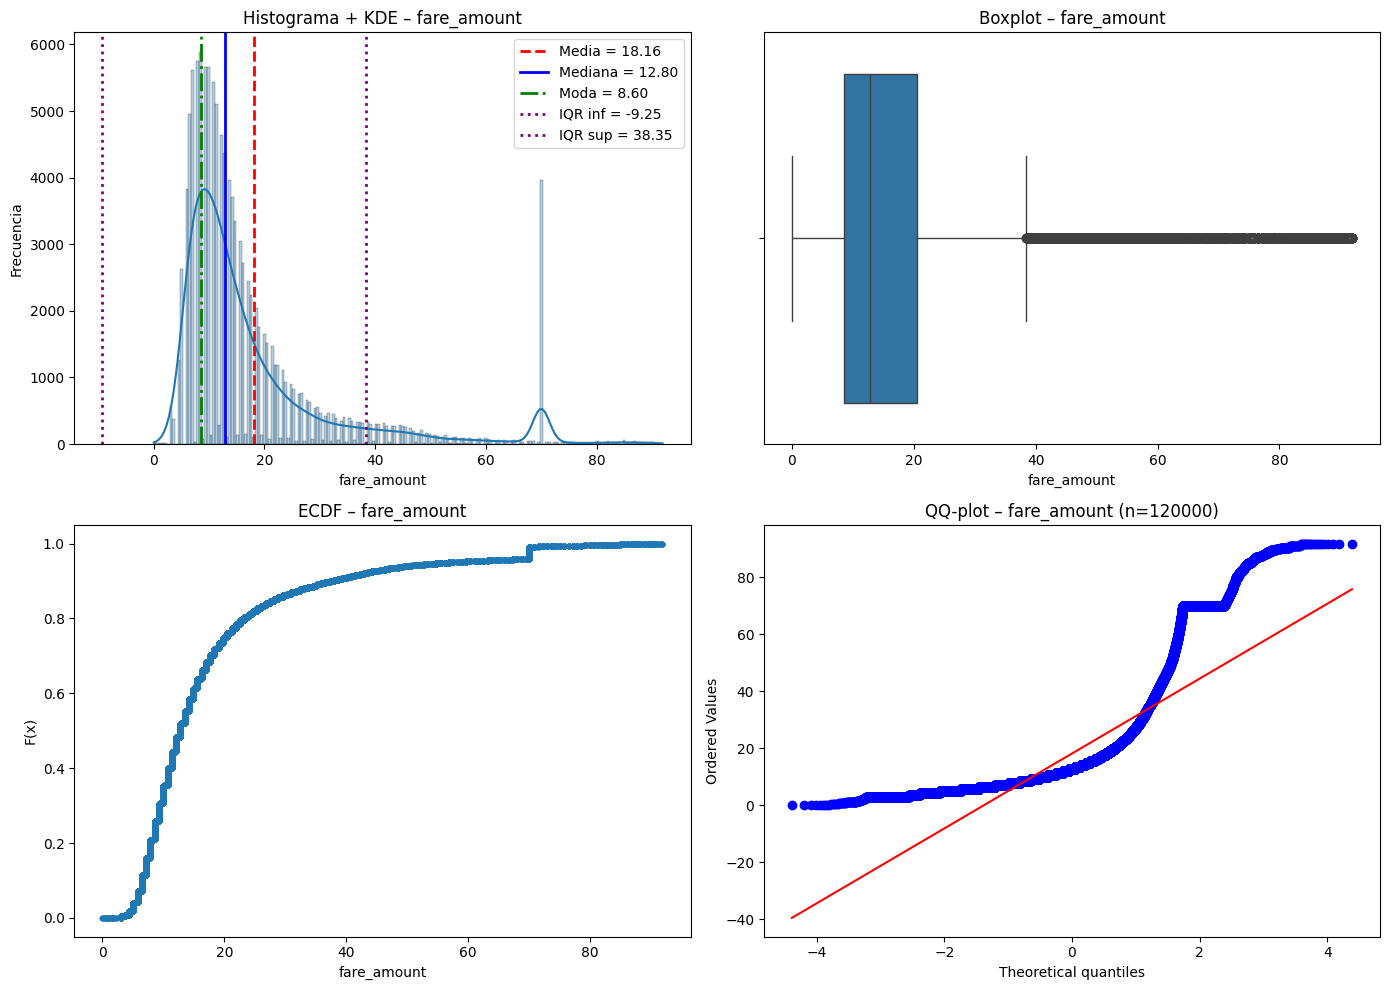

In [153]:
plots_numerica(df_fare_amount_clean, "fare_amount", sample_size=120000)

### vendor

In [158]:
df.head(5)

,Vendor,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,Ratecode,store_and_fwd_flag,payment_type,fare_amount,extra,...,congestion_surcharge,Airport_fee,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone,passenger_count_clean,trip_distance_bin
0,"Curb Mobility, LLC",2024-01-01 00:57:55,2024-01-01 01:17:43,1,1.72,Standard rate,N,Cash,17.70,1.00,...,2.50,0.00,Manhattan,Penn Station/Madison Sq West,Yellow Zone,Manhattan,East Village,Yellow Zone,1,"(1.68, 2.07]"
1,"Creative Mobile Technologies, LLC",2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.80,Standard rate,N,Credit card,10.00,3.50,...,2.50,0.00,Manhattan,Lenox Hill East,Yellow Zone,Manhattan,Upper East Side North,Yellow Zone,1,"(1.68, 2.07]"
2,"Creative Mobile Technologies, LLC",2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.70,Standard rate,N,Credit card,23.30,3.50,...,2.50,0.00,Manhattan,Upper East Side North,Yellow Zone,Manhattan,East Village,Yellow Zone,1,"(3.84, 8.42]"
3,"Creative Mobile Technologies, LLC",2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.40,Standard rate,N,Credit card,10.00,3.50,...,2.50,0.00,Manhattan,East Village,Yellow Zone,Manhattan,SoHo,Yellow Zone,1,"(1.37, 1.68]"
4,"Creative Mobile Technologies, LLC",2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.80,Standard rate,N,Credit card,7.90,3.50,...,2.50,0.00,Manhattan,SoHo,Yellow Zone,Manhattan,Lower East Side,Yellow Zone,1,"(0.6, 0.88]"


In [155]:
resumen_categoricas(df, cols=['Vendor'])


🔎 Distribución de valores para 'Vendor':


,frecuencia
Vendor,
"Curb Mobility, LLC",2234632
"Creative Mobile Technologies, LLC",729732
Myle Technologies Inc,260


,count,no_nulos,%_nulos,cardinalidad,moda,prop_moda,multimodal,freq_min,freq_max,rango_freq,entropia,entropia_max
variable,,,,,,,,,,,,
Vendor,2964624,2964624,0.00,3,"Curb Mobility, LLC",0.75,False,260,2234632,2234372,0.81,1.58


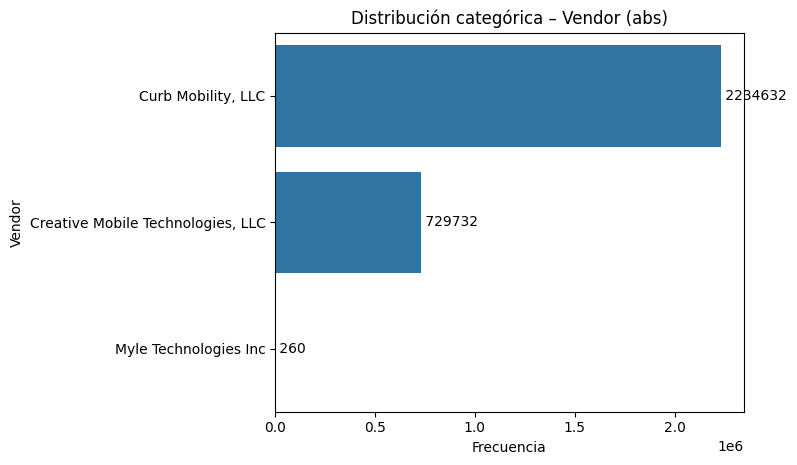

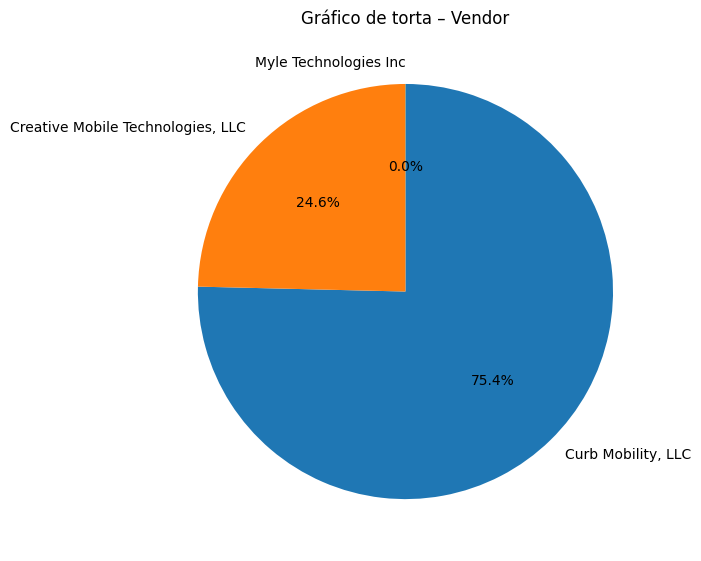

In [160]:
plots_categorica(df, "Vendor")

### Ratecode

In [161]:
resumen_categoricas(df, cols=['Ratecode'])


🔎 Distribución de valores para 'Ratecode':


,frecuencia
Ratecode,
Standard rate,2663350
JFK,98713
Null/unknown,28663
Negotiated fare,19410
Newark,7954
Nassau or Westchester,6365
Group ride,7


,count,no_nulos,%_nulos,cardinalidad,moda,prop_moda,multimodal,freq_min,freq_max,rango_freq,entropia,entropia_max
variable,,,,,,,,,,,,
Ratecode,2964624,2824462,4.73,7,Standard rate,0.94,False,7,2663350,2663343,0.41,2.81


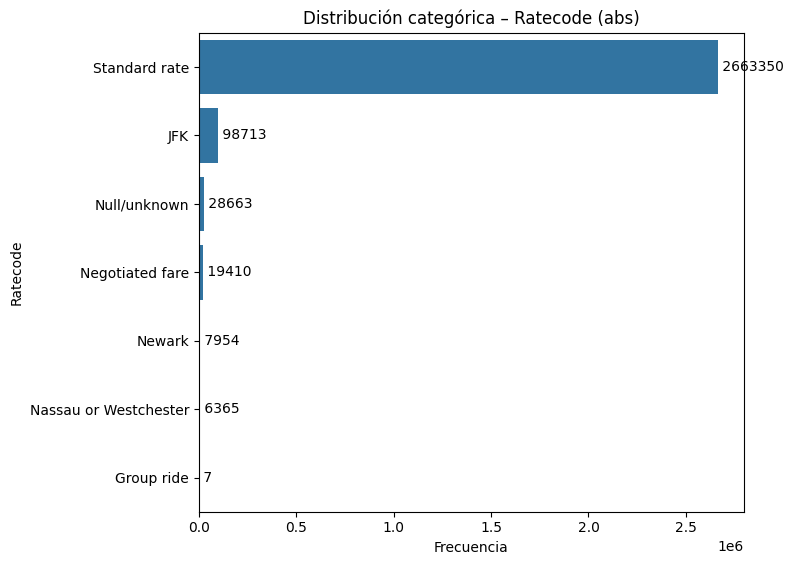

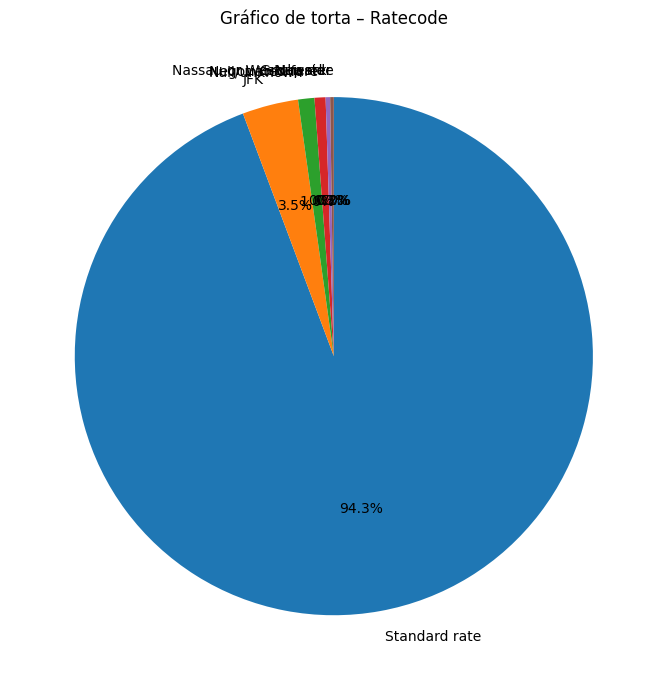

In [162]:
plots_categorica(df, "Ratecode")

### store_and_fwd_flag

### payment_type

In [165]:
resumen_categoricas(df, cols=['payment_type'])


🔎 Distribución de valores para 'payment_type':


,frecuencia
payment_type,
Credit card,2319046
Cash,439191
Flex Fare trip,140162
Dispute,46628
No charge,19597


,count,no_nulos,%_nulos,cardinalidad,moda,prop_moda,multimodal,freq_min,freq_max,rango_freq,entropia,entropia_max
variable,,,,,,,,,,,,
payment_type,2964624,2964624,0.00,5,Credit card,0.78,False,19597,2319046,2299449,1.04,2.32


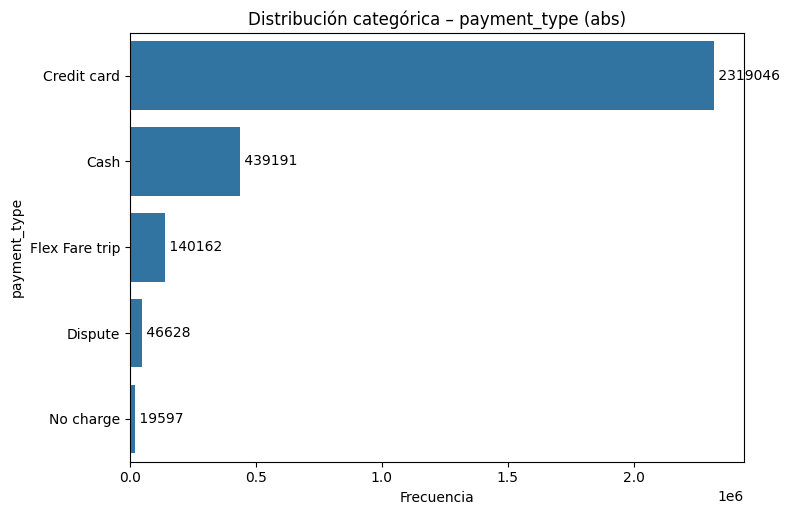

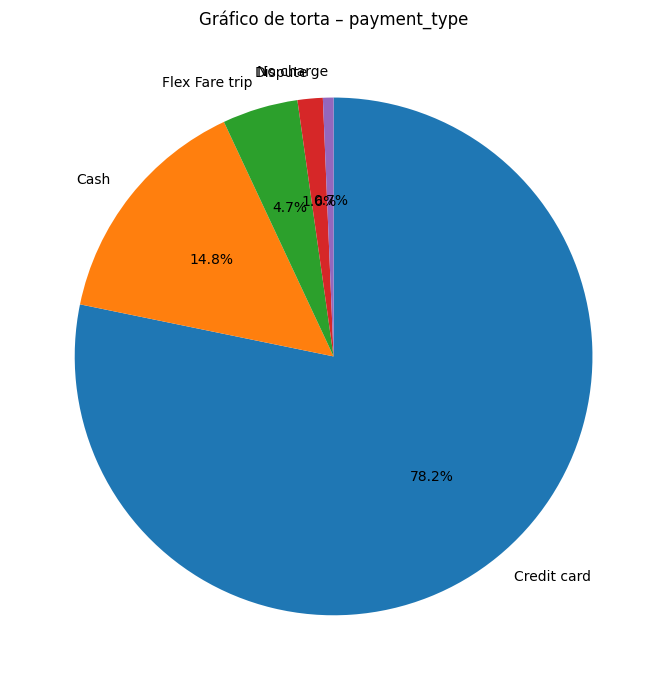

In [170]:
plots_categorica(df, "payment_type", use_others=False)


### pickup_zone

In [167]:
resumen_categoricas(df, cols=['pickup_zone'])


🔎 Distribución de valores para 'pickup_zone':
(Mostrando top 20 de 258 categorías únicas)


,frecuencia
pickup_zone,
JFK Airport,145240
Midtown Center,143471
Upper East Side South,142708
Upper East Side North,136465
Midtown East,106717
Times Sq/Theatre District,106324
Penn Station/Madison Sq West,104523
Lincoln Square East,104080
LaGuardia Airport,89533


,count,no_nulos,%_nulos,cardinalidad,moda,prop_moda,multimodal,freq_min,freq_max,rango_freq,entropia,entropia_max
variable,,,,,,,,,,,,
pickup_zone,2964624,2954264,0.35,258,JFK Airport,0.05,False,1,145240,145239,5.58,8.01


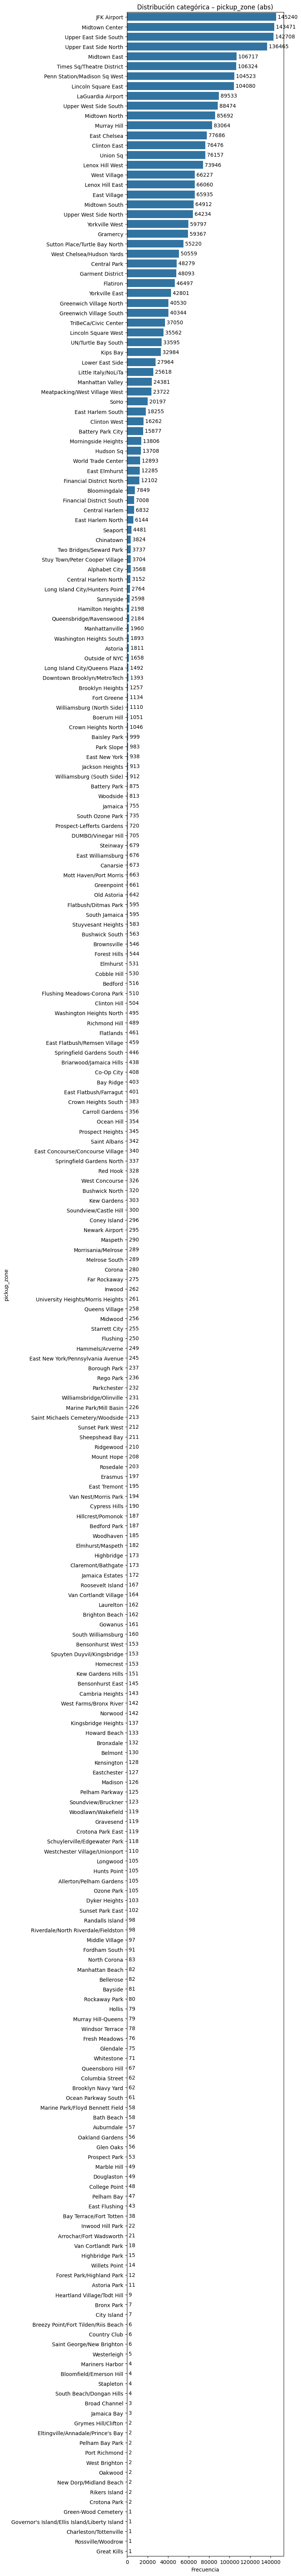

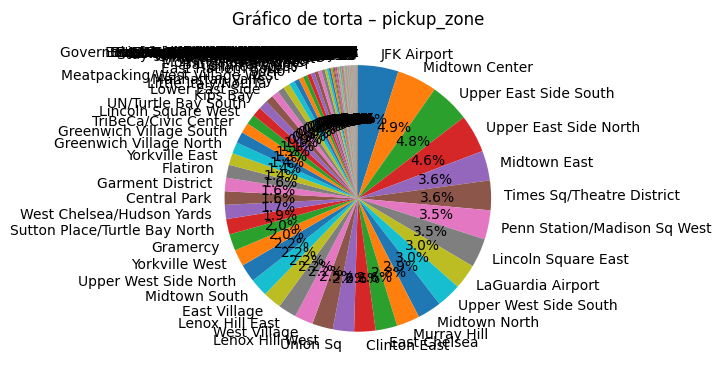

In [ ]:
plots_categorica(df, "pickup_zone", use_others=False)

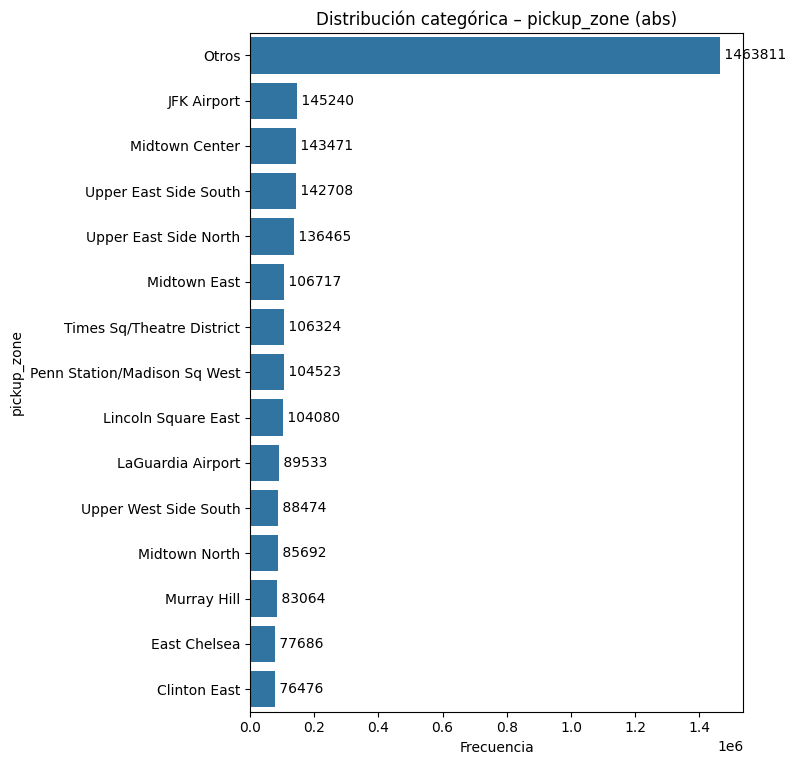

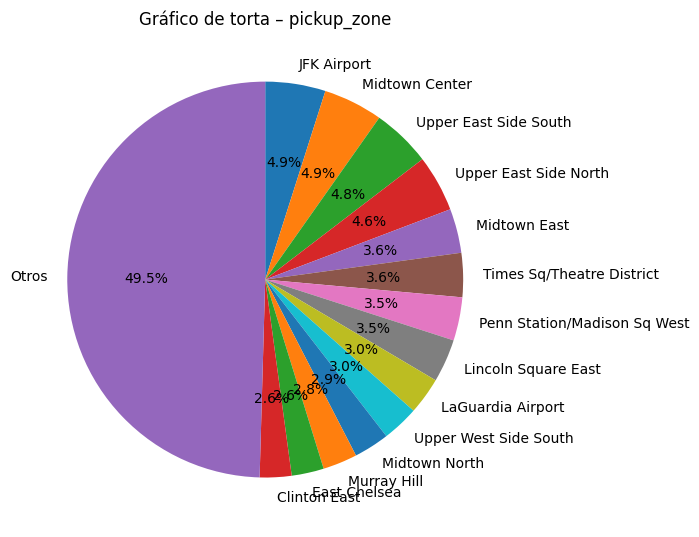

In [ ]:
plots_categorica(df, "pickup_zone", use_others=True)

In [180]:
import geopandas as gpd
import matplotlib.pyplot as plt

def mapa_heatmap_nyc(
    df,
    group_col="pickup_zone",              # columna en tu df
    agg="count",                          # "count" o "mean"
    value_col=None,                       # si agg = "mean"
    zones_path=r"..\dataset\taxi_zones\taxi_zones.shp",
    zones_key="zone",                     # columna del SHP que coincide con group_col
    title=None,
    cmap="magma"
):
    """
    Crea un mapa heatmap de NYC usando tus columnas ya mapeadas (pickup_zone, borough, etc.)
    """

    # 1) Leer shapefile
    zonas = gpd.read_file(zones_path)

    # 2) Crear métrica de agregación
    if agg == "count":
        agg_df = (
            df.groupby(group_col)
              .size()
              .rename("valor")
              .reset_index()
        )
    elif agg == "mean":
        if value_col is None:
            raise ValueError("Para agg='mean' se requiere value_col")
        agg_df = (
            df.groupby(group_col)[value_col]
              .mean()
              .rename("valor")
              .reset_index()
        )
    else:
        raise ValueError("agg debe ser 'count' o 'mean'")

    # 3) Merge entre shapefile (zonas) y tus datos (df)
    zonas_mapa = zonas.merge(
        agg_df,
        left_on=zones_key,     # ej. 'zone' en el SHP
        right_on=group_col,    # ej. 'pickup_zone' en tu df
        how="left"
    )

    zonas_mapa["valor"] = zonas_mapa["valor"].fillna(0)

    # 4) Plot del mapa
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))

    zonas_mapa.plot(
        column="valor",
        ax=ax,
        cmap=cmap,
        legend=True,
        edgecolor="black",
        linewidth=0.2
    )

    ax.set_axis_off()

    if title is None:
        title = f"Heatmap NYC – {group_col}"
    ax.set_title(title, fontsize=14)

    plt.tight_layout()
    plt.show()


In [181]:
import geopandas as gpd
zones = gpd.read_file(r"..\dataset\taxi_zones\taxi_zones.shp")
zones.columns


Index(['OBJECTID', 'Shape_Leng', 'Shape_Area', 'zone', 'LocationID', 'borough',
       'geometry'],
      dtype='object')

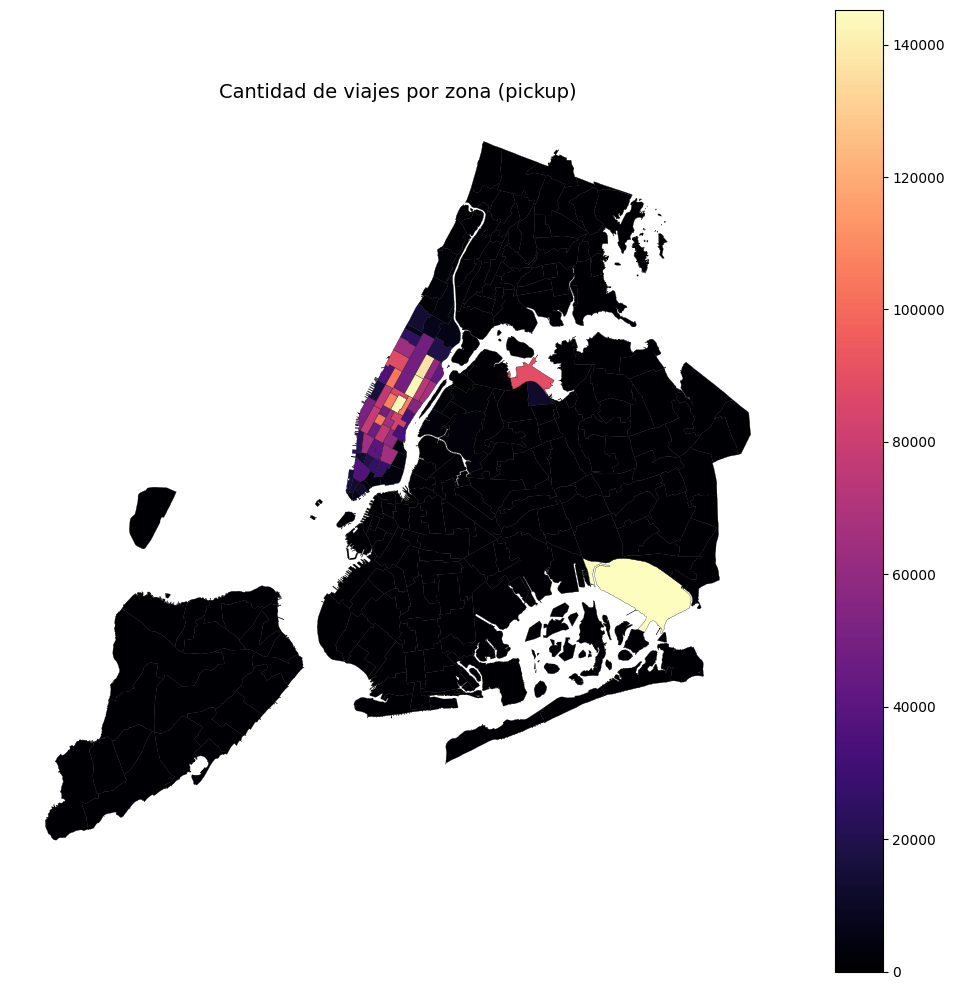

In [182]:
mapa_heatmap_nyc(
    df,
    group_col="pickup_zone",
    agg="count",
    title="Cantidad de viajes por zona (pickup)"
)


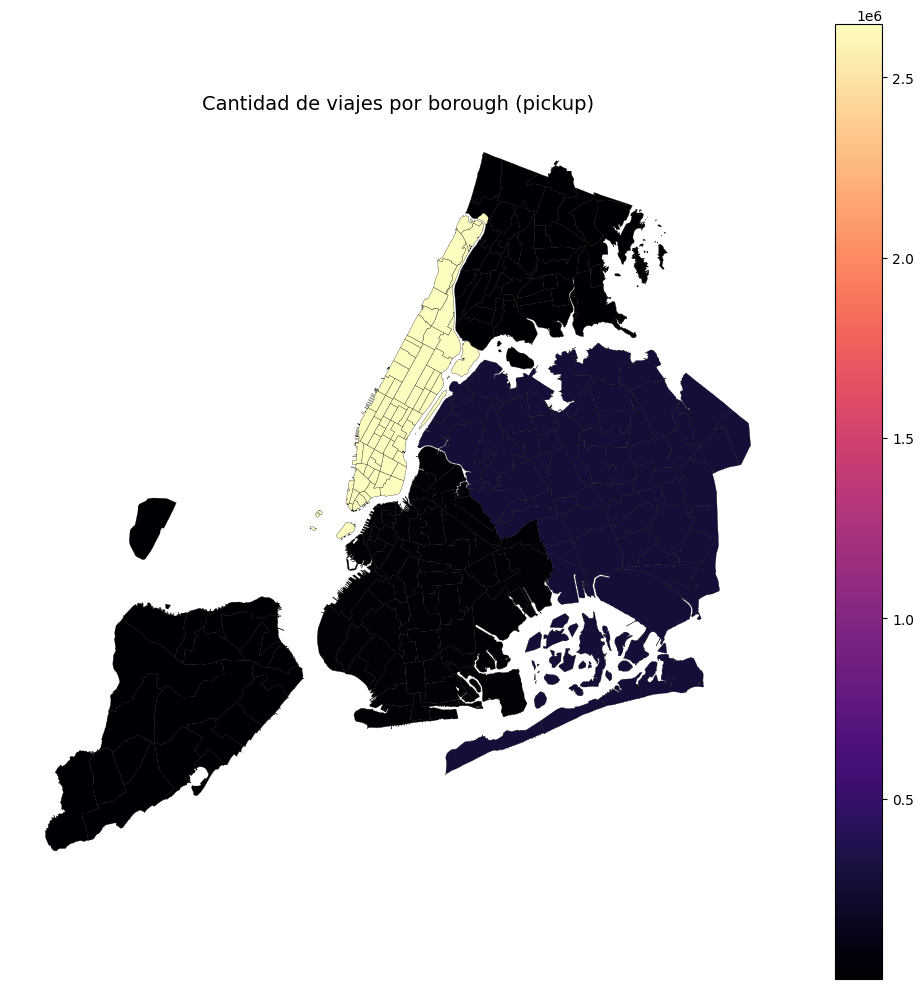

In [183]:
mapa_heatmap_nyc(
    df,
    group_col="pickup_borough",
    agg="count",
    zones_key="borough",
    title="Cantidad de viajes por borough (pickup)"
)


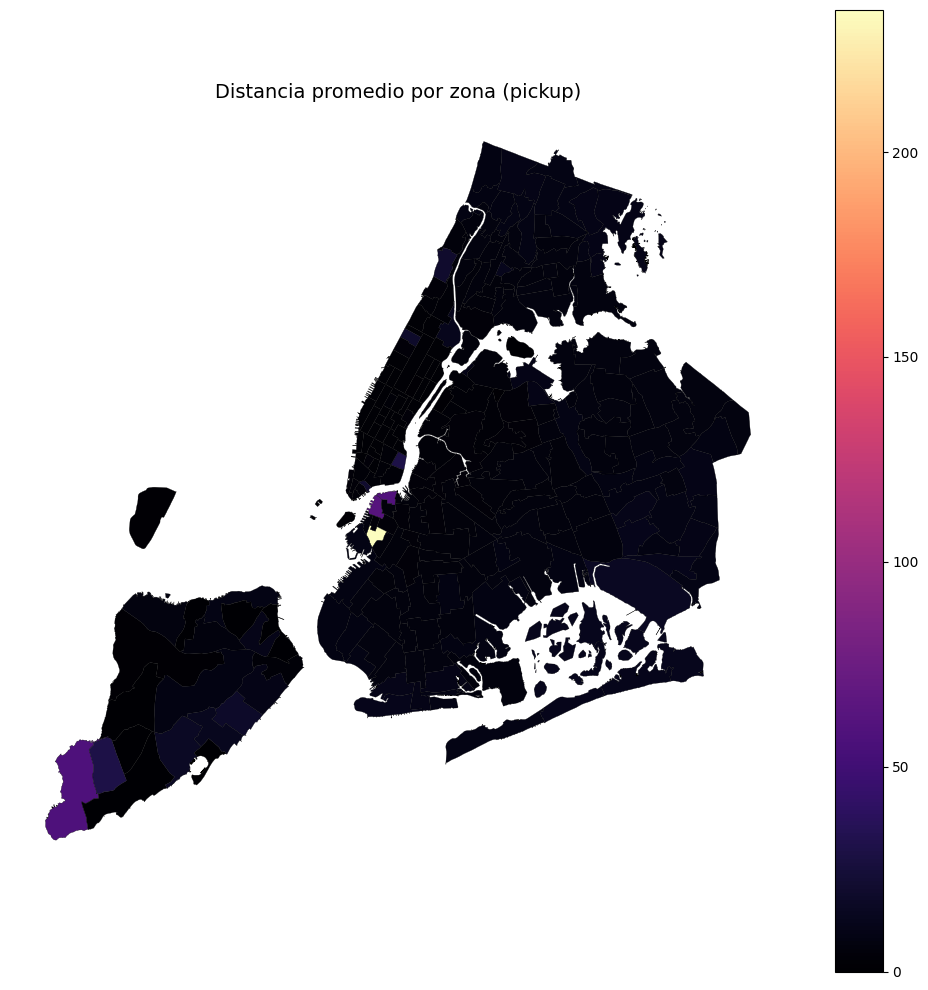

In [184]:
mapa_heatmap_nyc(
    df,
    group_col="pickup_zone",
    agg="mean",
    value_col="trip_distance",
    title="Distancia promedio por zona (pickup)"
)


In [185]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

def mapa_heatmap_nyc(
    df,
    group_col="pickup_zone",
    agg="count",
    value_col=None,
    zones_path=r"..\dataset\taxi_zones\taxi_zones.shp",
    zones_key="zone",
    title=None,
    cmap="magma",
    log_scale=False,
    vmax_quantile=None,      # ej. 0.95 para capar en p95
    focus_borough=None       # ej. "Manhattan" si querés zoom
):
    """
    Mapa heatmap de NYC usando tus columnas (pickup_zone, pickup_borough, etc.)
    Con opciones de:
      - log_scale: escala logarítmica en la métrica
      - vmax_quantile: recortar escala en un percentil (p.ej. 0.95)
      - focus_borough: filtrar a un borough (usa columna 'borough' del shapefile)
    """
    zonas = gpd.read_file(zones_path)

    # Filtrar solo un borough si se pide
    if focus_borough is not None and "borough" in zonas.columns:
        zonas = zonas[zonas["borough"] == focus_borough]

    # Agregación
    if agg == "count":
        agg_df = (
            df.groupby(group_col)
              .size()
              .rename("valor")
              .reset_index()
        )
    elif agg == "mean":
        if value_col is None:
            raise ValueError("Para agg='mean' tenés que pasar value_col")
        agg_df = (
            df.groupby(group_col)[value_col]
              .mean()
              .rename("valor")
              .reset_index()
        )
    else:
        raise ValueError("agg debe ser 'count' o 'mean'")

    # Merge
    zonas_mapa = zonas.merge(
        agg_df,
        left_on=zones_key,
        right_on=group_col,
        how="left"
    )
    zonas_mapa["valor"] = zonas_mapa["valor"].fillna(0)

    # Transformaciones para el color
    vals = zonas_mapa["valor"].astype(float)

    if log_scale:
        vals_plot = np.log1p(vals)
    else:
        vals_plot = vals

    vmin = vals_plot.min()
    if vmax_quantile is not None:
        vmax = vals_plot.quantile(vmax_quantile)
    else:
        vmax = vals_plot.max()

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    zonas_mapa.plot(
        column=vals_plot,
        ax=ax,
        cmap=cmap,
        legend=True,
        vmin=vmin,
        vmax=vmax,
        edgecolor="black",
        linewidth=0.2
    )

    ax.set_axis_off()
    if title is None:
        title = f"Heatmap NYC – {group_col}"
    ax.set_title(title, fontsize=14)
    plt.tight_layout()
    plt.show()


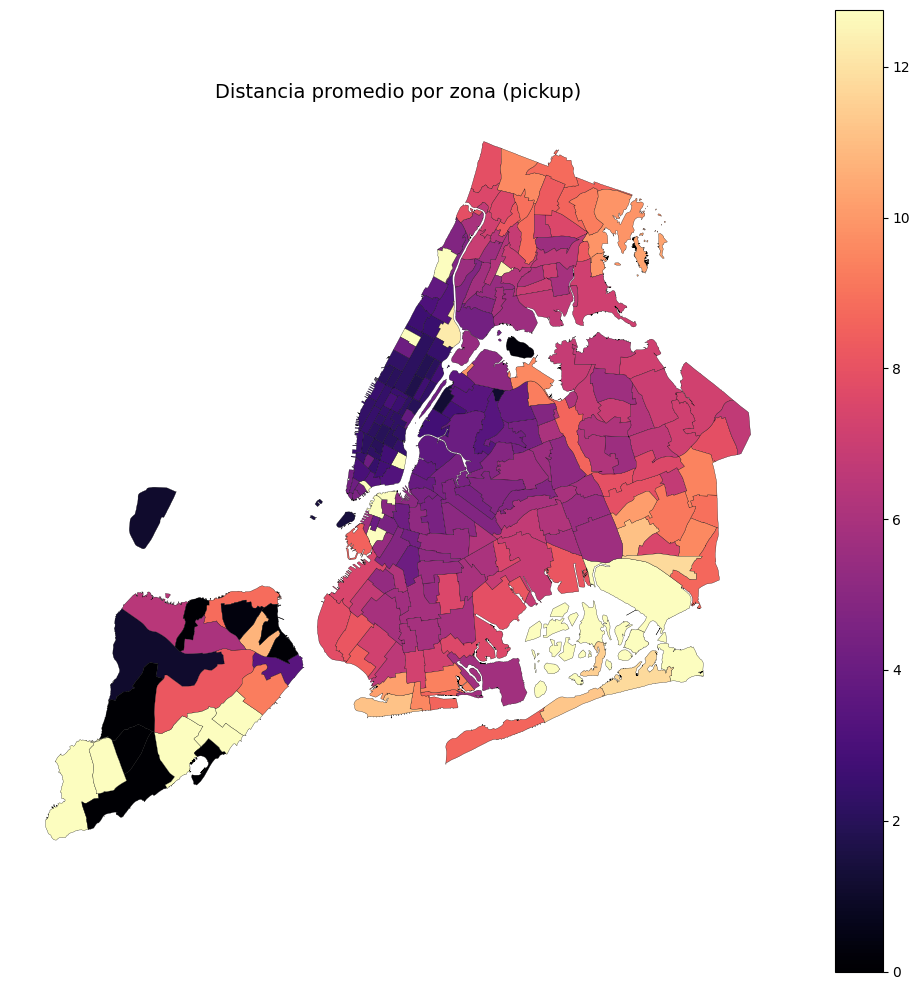

In [186]:
mapa_heatmap_nyc(
    df,
    group_col="pickup_zone",
    agg="mean",
    value_col="trip_distance",
    title="Distancia promedio por zona (pickup)",
    vmax_quantile=0.95
)


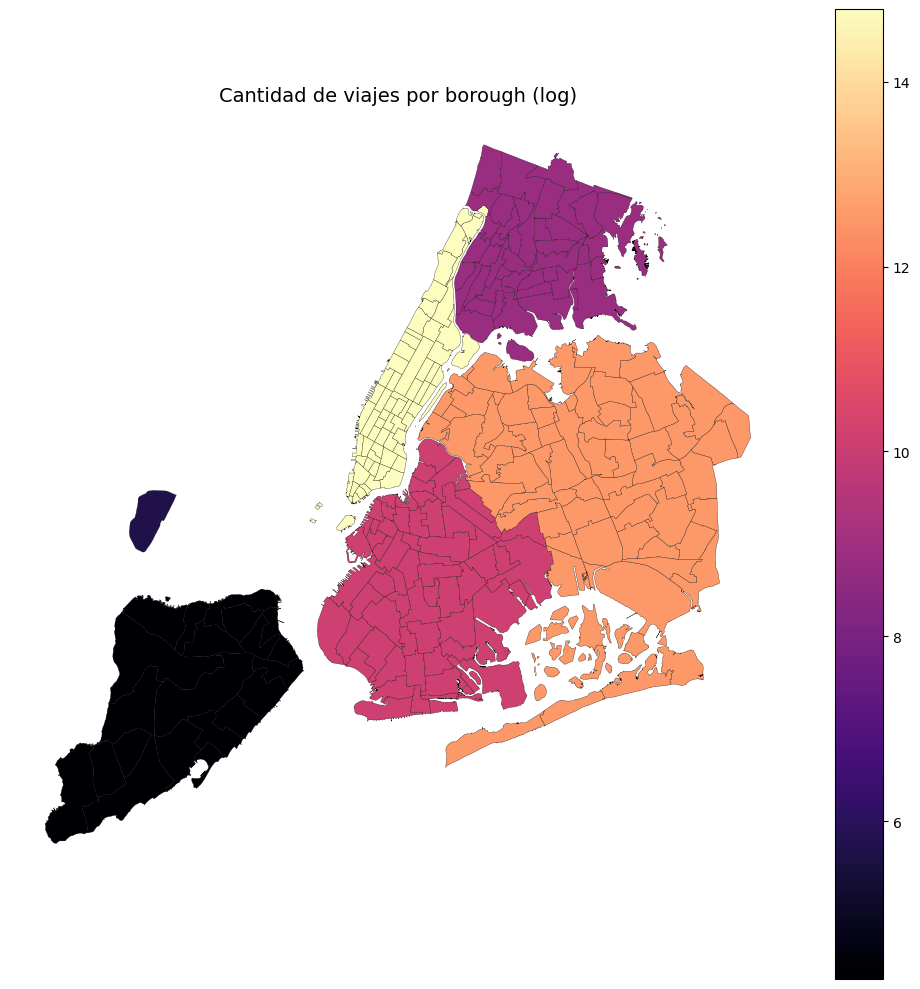

In [ ]:
mapa_heatmap_nyc(
    df,
    group_col="pickup_borough",
    agg="count",
    zones_key="borough",
    title="Cantidad de viajes por borough (log)",
    log_scale=True
)

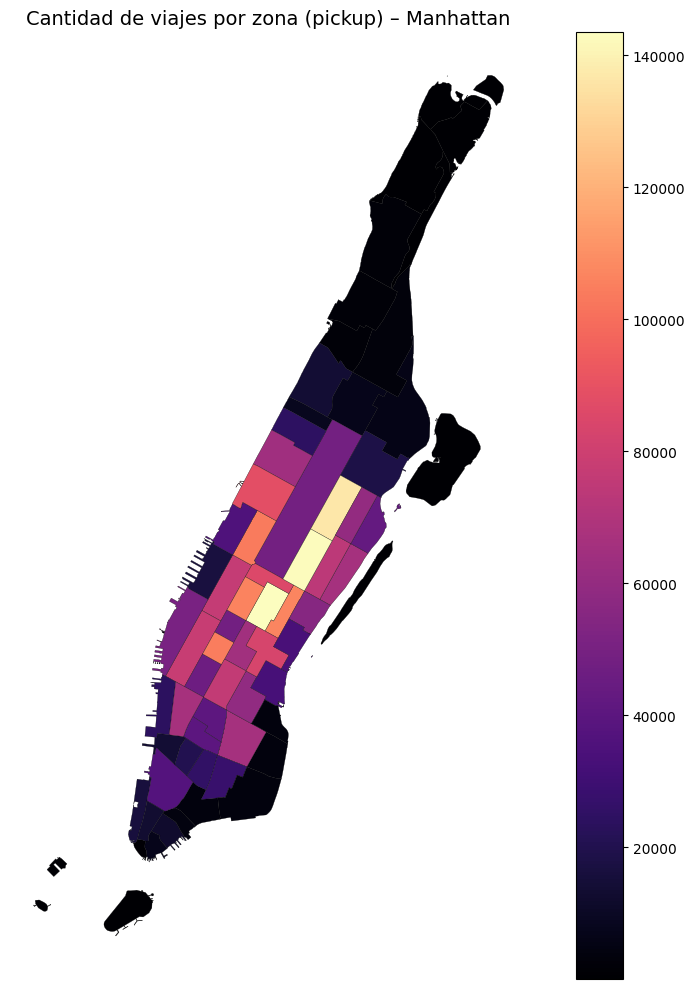

In [190]:
mapa_heatmap_nyc(
    df,
    group_col="pickup_zone",
    agg="count",
    title="Cantidad de viajes por zona (pickup) – Manhattan",
    focus_borough="Manhattan"
)


### dropoff_zone

## Var temporales

### tpep_pickup_datetime

In [97]:
MES = 1  # mes que querés analizar

df_fechas = df[
    (df["tpep_pickup_datetime"].dt.month == MES) &
    (df["tpep_dropoff_datetime"].dt.month == MES)
]


In [ ]:
def resumen_temporal(df, col, mes_esperado=None):
    """
    EDA univariado para columnas datetime.
    Incluye:
      - métricas básicas
      - distribución por día del mes
      - distribución por hora del día
      - distribución por día de la semana
      - heatmap hora × día
      - control opcional del mes esperado
    """

    serie = df[col].dropna()

    print(f"\n===== Análisis temporal: {col} =====")
    print(f"Total registros: {len(df)}")
    print(f"No nulos: {len(serie)} | Nulos: {df[col].isna().sum()}")

    if len(serie) == 0:
        print("La columna no tiene fechas válidas.")
        return
    
    # ---- Estadísticos básicos ----
    min_dt = serie.min()
    max_dt = serie.max()
    rango = max_dt - min_dt

    print(f"Fecha mínima: {min_dt}")
    print(f"Fecha máxima: {max_dt}")
    print(f"Rango total: {rango} (≈ {rango.days} días)")

    # ---- Control del mes esperado ----
    if mes_esperado is not None:
        meses_presentes = serie.dt.month.unique()
        print(f"\nMes(es) presentes: {sorted(meses_presentes)}")
        if mes_esperado in meses_presentes and len(meses_presentes) == 1:
            print("✔️ CONSISTENTE: todas las fechas pertenecen al mes esperado.")
        else:
            print("⚠️ ATENCIÓN: hay meses que no coinciden con el esperado.\n")

    # ---- Componentes temporales ----
    dias_mes = serie.dt.day                # 1–31
    horas = serie.dt.hour                  # 0–23
    dias_semana = serie.dt.dayofweek       # 0–6

    # =============== G R Á F I C O S ==================

    fig, ax = plt.subplots(4, 1, figsize=(16, 20))

    # 1) Distribución por día del mes
    sns.countplot(x=dias_mes, ax=ax[0])
    ax[0].set_title("Distribución por día del mes")
    ax[0].set_xlabel("Día del mes (1–31)")
    ax[0].set_ylabel("Cantidad de viajes")

    # 2) Distribución por hora del día
    sns.countplot(x=horas, ax=ax[1])
    ax[1].set_title("Distribución por hora del día")
    ax[1].set_xlabel("Hora (0–23)")
    ax[1].set_ylabel("Cantidad de viajes")

    # 3) Distribución por día de la semana
    sns.countplot(x=dias_semana, ax=ax[2])
    ax[2].set_title("Distribución por día de la semana")
    ax[2].set_xlabel("Día (0=Lun … 6=Dom)")
    ax[2].set_ylabel("Cantidad de viajes")

    # 4) Heatmap hora × día
    cross = df.loc[serie.index].copy()
    cross["hora"] = cross[col].dt.hour
    cross["dia_sem"] = cross[col].dt.dayofweek

    tabla = cross.pivot_table(
        index="dia_sem",
        columns="hora",
        values=col,
        aggfunc="count"
    )

    sns.heatmap(tabla, cmap="YlOrRd", ax=ax[3])
    ax[3].set_title("Heatmap: viajes por hora × día de la semana")
    ax[3].set_xlabel("Hora del día")
    ax[3].set_ylabel("Día de la semana (0=Lun … 6=Dom)")

    plt.tight_layout()
    plt.show()

    return {
        "min": min_dt,
        "max": max_dt,
        "rango_dias": rango.days,
        "n_total": len(df),
        "n_validos": len(serie),
        "n_nulos": df[col].isna().sum(),
        "meses_presentes": sorted(serie.dt.month.unique())
    }



===== Análisis temporal: tpep_pickup_datetime =====
Total registros: 2964009
No nulos: 2964009 | Nulos: 0
Fecha mínima: 2009-01-01 00:24:09
Fecha máxima: 2024-01-31 23:59:29
Rango total: 5508 days 23:35:20 (≈ 5508 días)

Mes(es) presentes: [np.int32(1)]
✔️ CONSISTENTE: todas las fechas pertenecen al mes esperado.


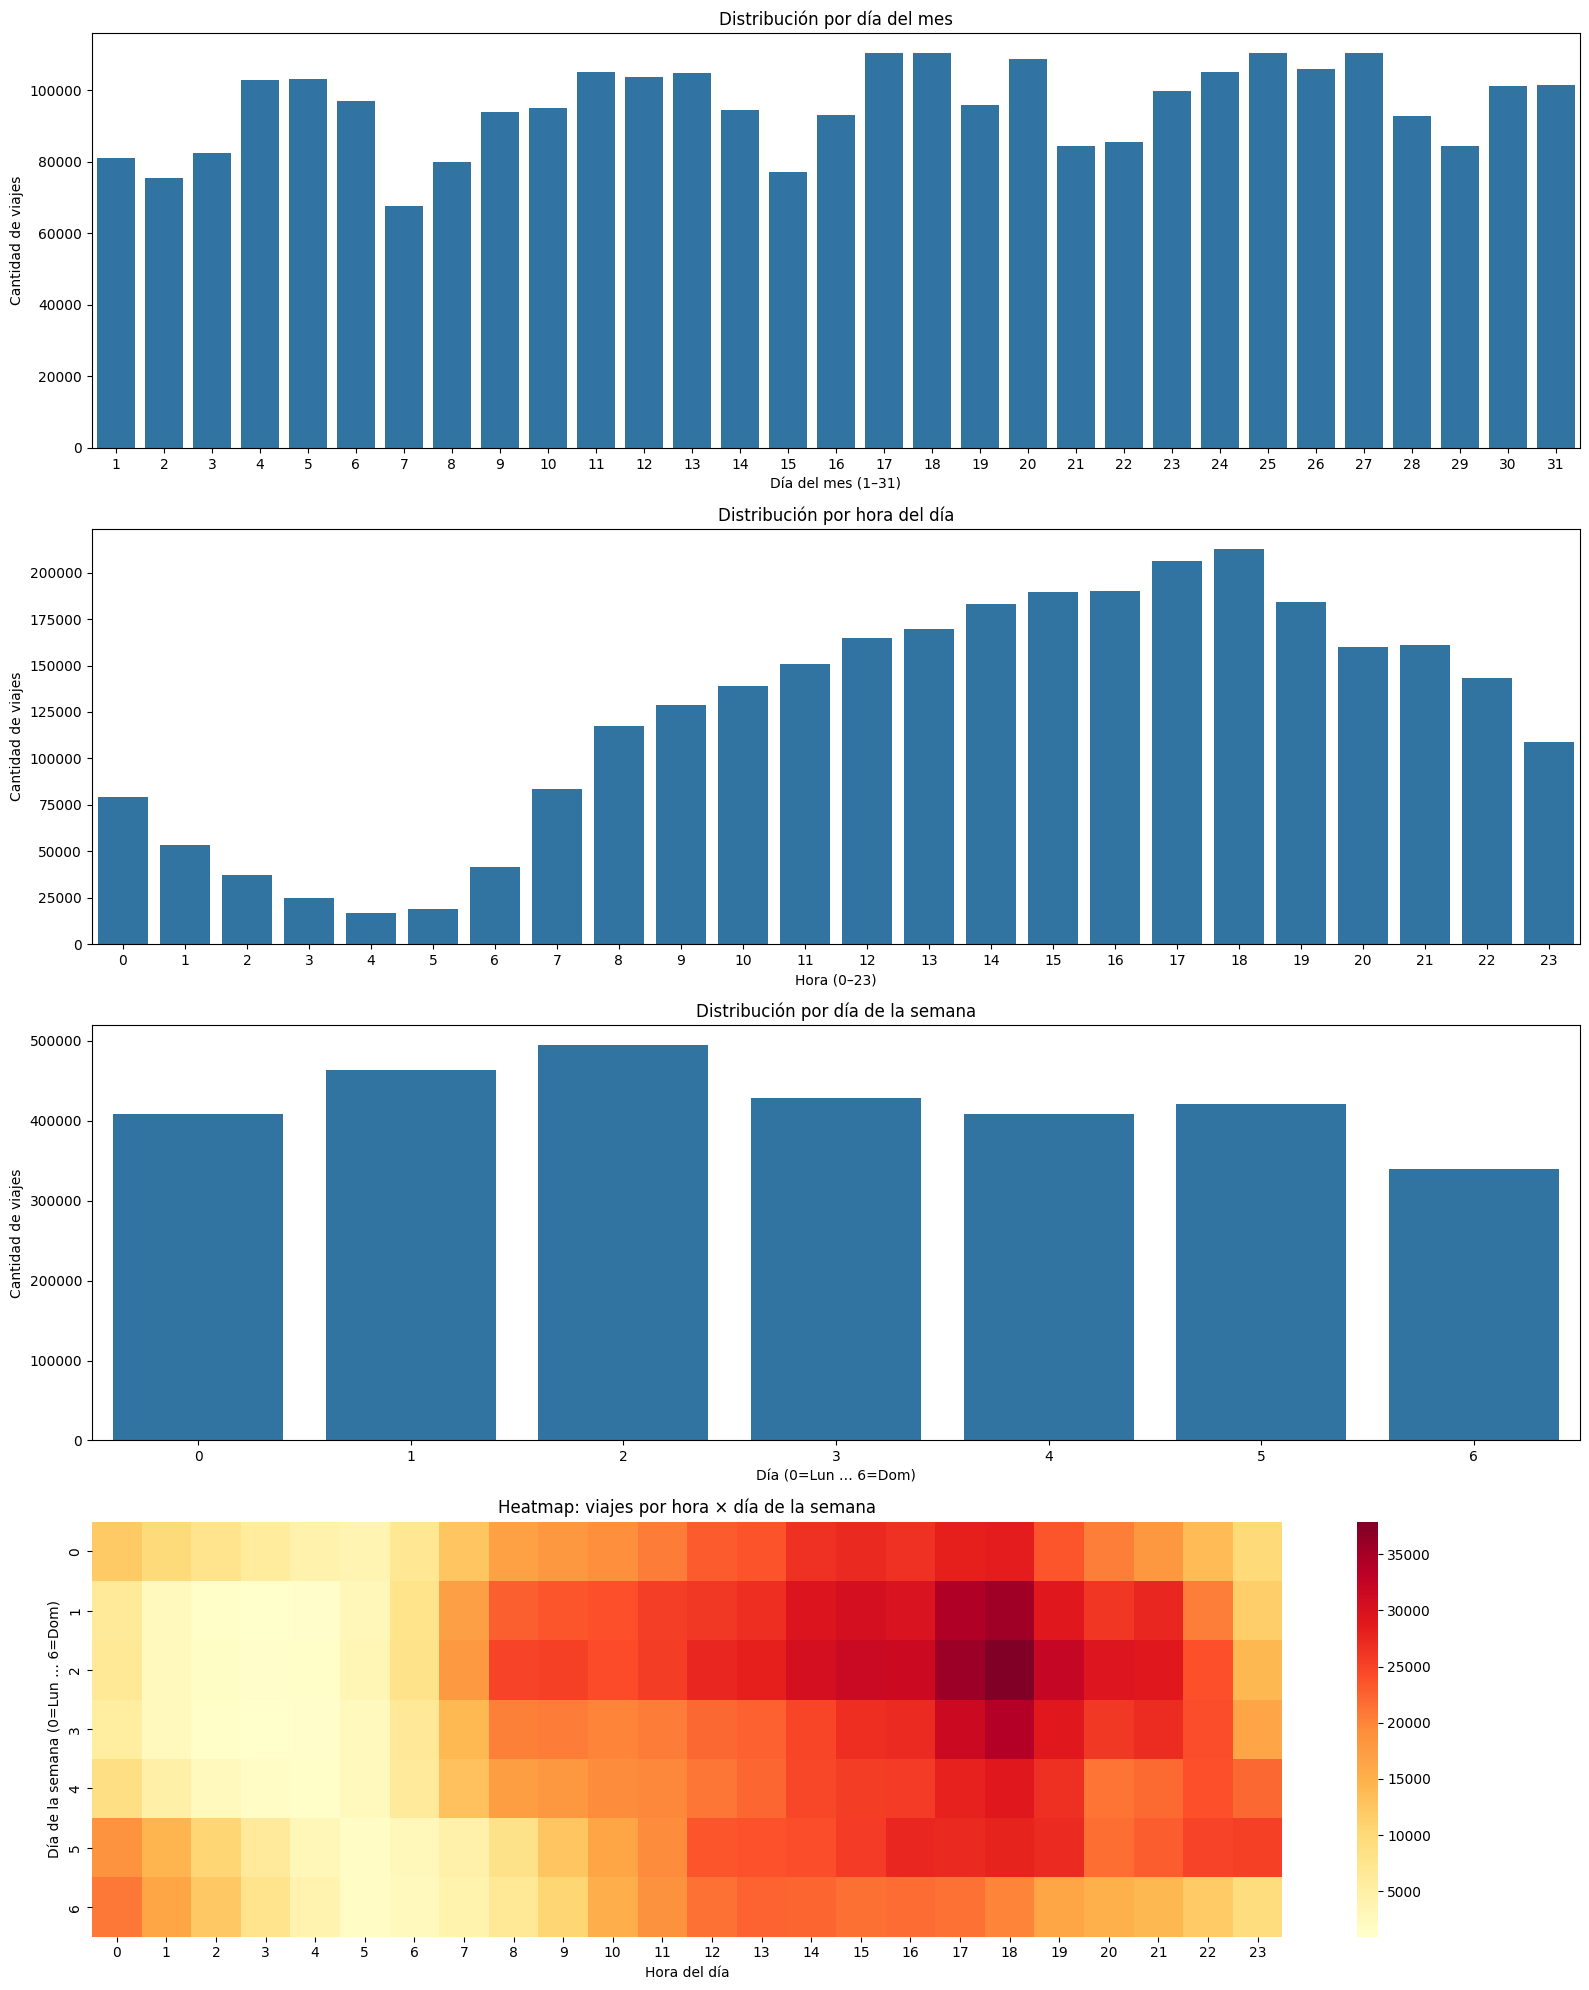

{'min': Timestamp('2009-01-01 00:24:09'),
 'max': Timestamp('2024-01-31 23:59:29'),
 'rango_dias': 5508,
 'n_total': 2964009,
 'n_validos': 2964009,
 'n_nulos': np.int64(0),
 'meses_presentes': [np.int32(1)]}

In [93]:
resumen_temporal(df_fechas, "tpep_pickup_datetime", mes_esperado=1)

### tpep_dropoff_datetime


===== Análisis temporal: tpep_dropoff_datetime =====
Total registros: 2964009
No nulos: 2964009 | Nulos: 0
Fecha mínima: 2009-01-01 01:13:00
Fecha máxima: 2024-01-31 23:59:59
Rango total: 5508 days 22:46:59 (≈ 5508 días)

Mes(es) presentes: [np.int32(1)]
✔️ CONSISTENTE: todas las fechas pertenecen al mes esperado.


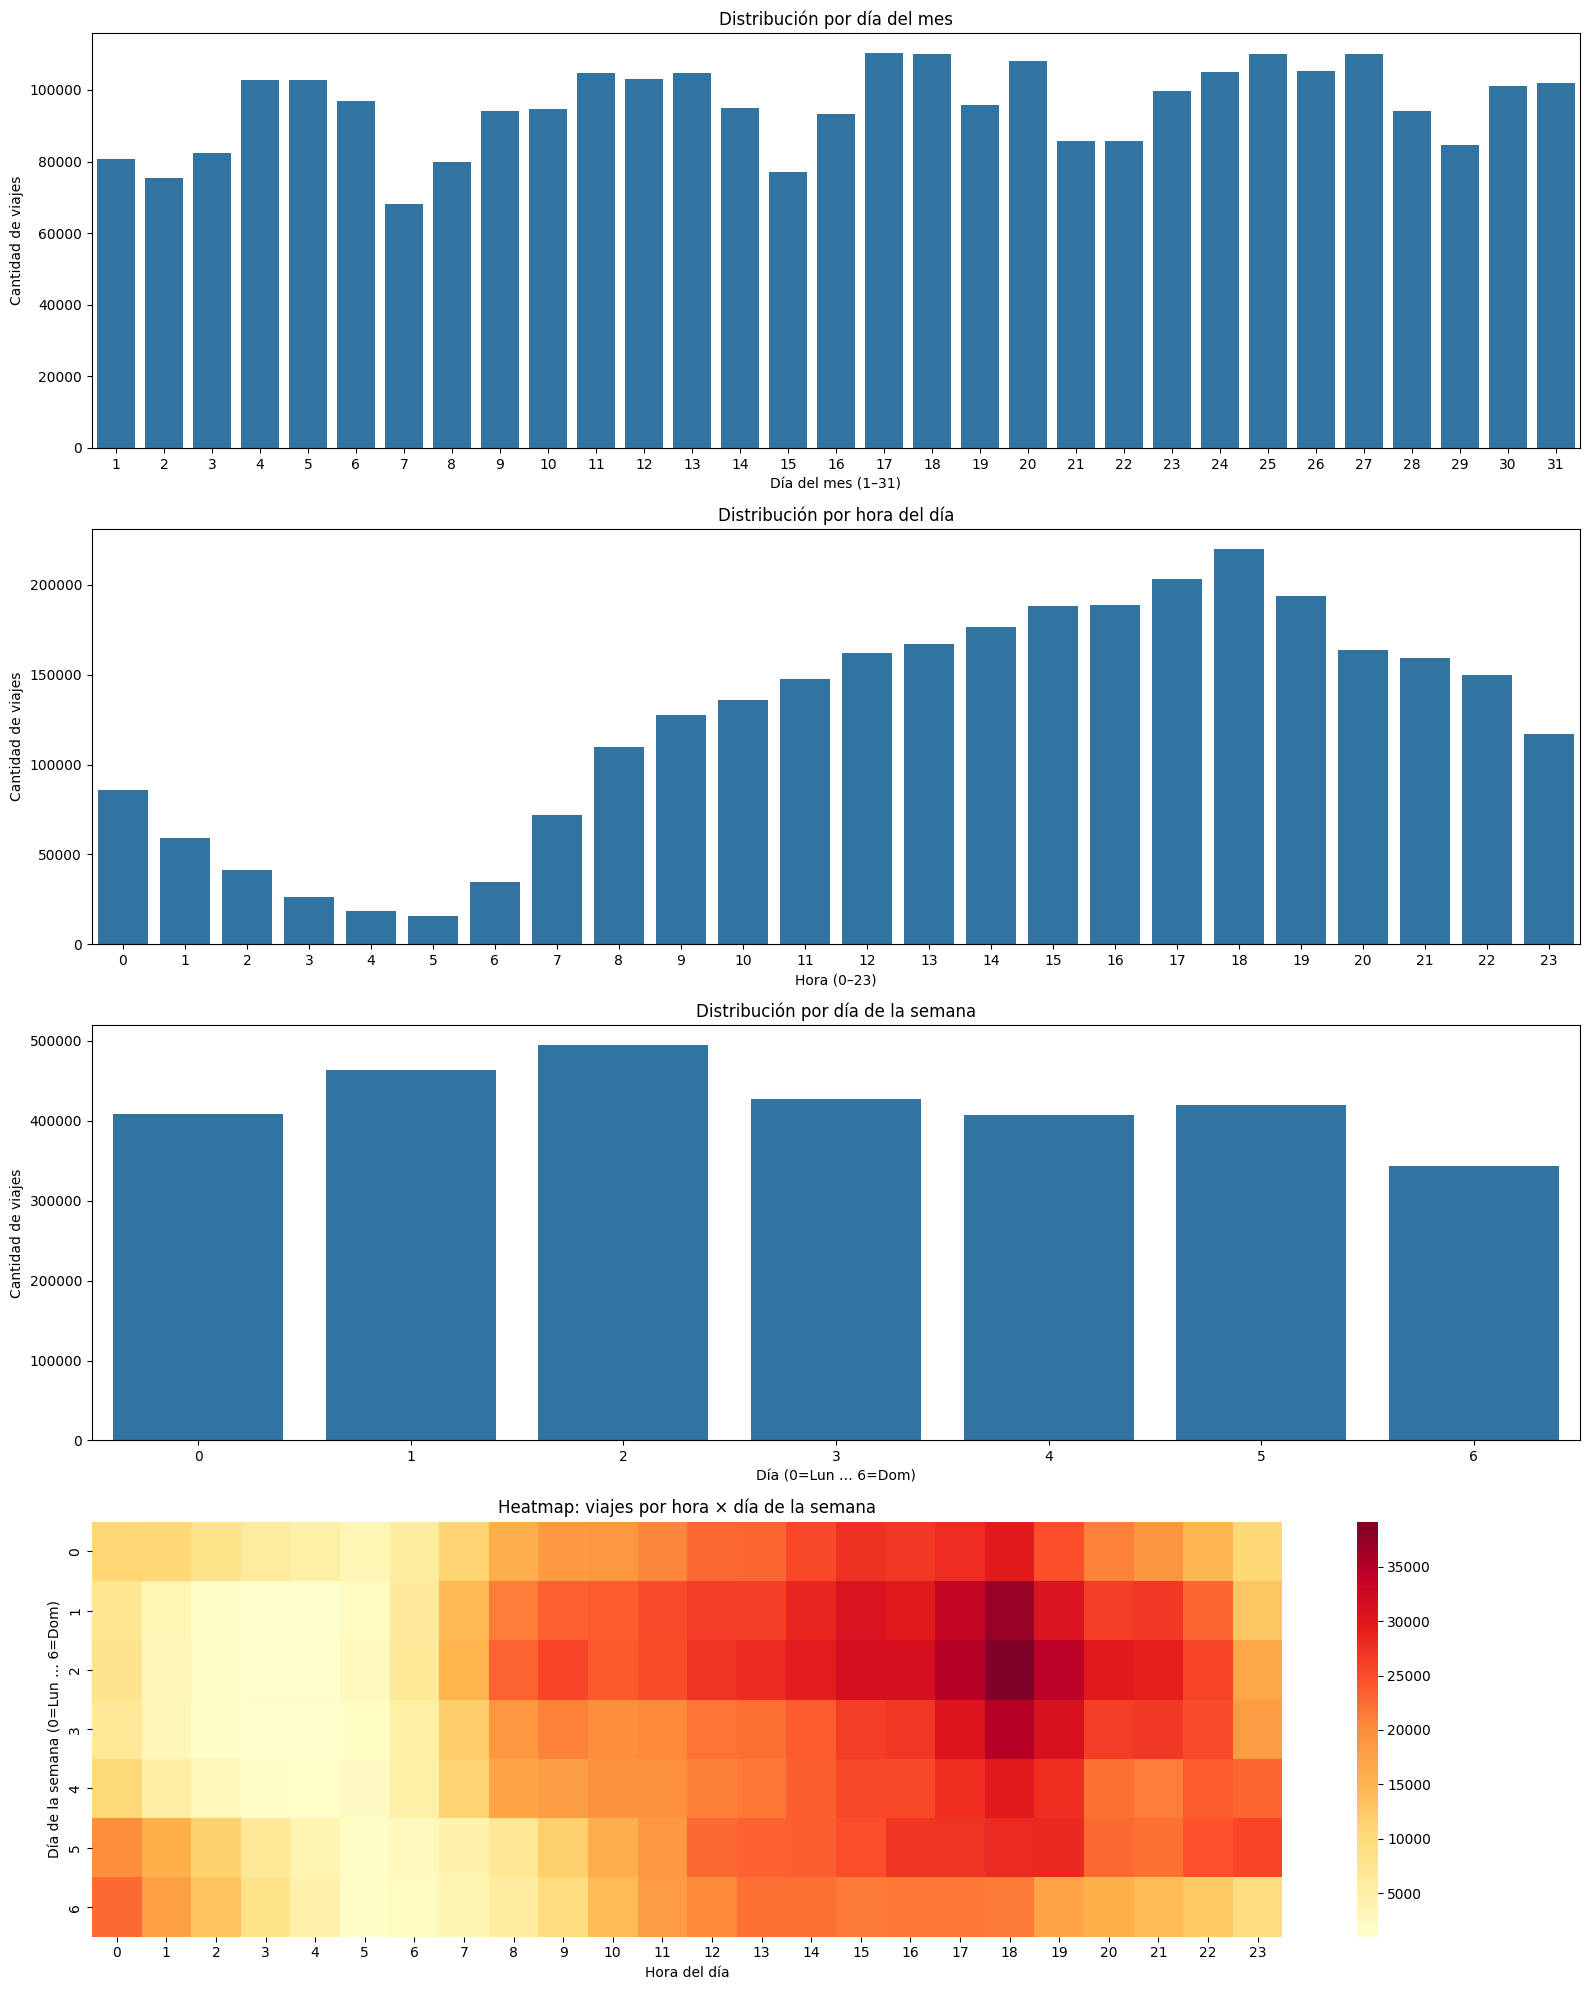

{'min': Timestamp('2009-01-01 01:13:00'),
 'max': Timestamp('2024-01-31 23:59:59'),
 'rango_dias': 5508,
 'n_total': 2964009,
 'n_validos': 2964009,
 'n_nulos': np.int64(0),
 'meses_presentes': [np.int32(1)]}

In [94]:
resumen_temporal(df_fechas, "tpep_dropoff_datetime", mes_esperado=1)

In [110]:
df_fechas = df[df["tpep_pickup_datetime"].dt.month == 1].copy()

df_fechas["duracion_min"] = (
    df_fechas["tpep_dropoff_datetime"] - df_fechas["tpep_pickup_datetime"]
).dt.total_seconds() / 60


In [111]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def analisis_pickup_dropoff(
    df,
    pickup_col="tpep_pickup_datetime",
    dropoff_col="tpep_dropoff_datetime",
    dist_col="trip_distance",
    eliminar_invalidos=True
):
    """
    Análisis completo de pickup + dropoff:
      - Cálculo de duración en minutos.
      - Reporte de media, mediana y moda.
      - Detección y filtrado de duraciones negativas.
      - Histograma y boxplots de duración (con y sin outliers extremos).
      - Duración según hora del día y día de la semana
        (sin filtrar y filtrando outliers por p99).
      - Relación duración vs distancia (sin filtrar y filtrado p99 en ambas variables, más versión log).
    Devuelve un df copia, con la columna 'duracion_min' y sin duraciones negativas
    si eliminar_invalidos=True.
    """

    df = df.copy()  # para no tocar el original

    print("\n===== ANÁLISIS PICKUP + DROPOFF =====")

    # --------------------------------------------------
    # 1) Cálculo de duración
    # --------------------------------------------------
    df["duracion_min"] = (df[dropoff_col] - df[pickup_col]).dt.total_seconds() / 60
    dur = df["duracion_min"]

    media = dur.mean()
    mediana = dur.median()
    mode_series = dur.mode()
    moda = mode_series.iloc[0] if not mode_series.empty else np.nan

    print(f"\nDuración (incluyendo negativas):")
    print(f"  Mínima: {dur.min():.2f} min")
    print(f"  Máxima: {dur.max():.2f} min")
    print(f"  Media:  {media:.2f} min")
    print(f"  Mediana:{mediana:.2f} min")
    print(f"  Moda:   {moda:.2f} min")

    # --------------------------------------------------
    # 2) Viajes inválidos: duración negativa
    # --------------------------------------------------
    invalid = df[dur < 0]
    n_invalid = len(invalid)
    print(f"\nViajes con duración negativa: {n_invalid}")

    if n_invalid > 0:
        print(f"⚠️  Se detectaron {n_invalid} viajes con duración negativa.")
        if eliminar_invalidos:
            print("   → Estos viajes serán ELIMINADOS del análisis.")
        else:
            print("   → NO se eliminarán (pero son duraciones inválidas).")

        plt.figure(figsize=(8, 4))
        sns.histplot(invalid["duracion_min"], bins=20, color="red")
        plt.title("Duraciones negativas (viajes inválidos)")
        plt.xlabel("Duración (min)")
        plt.show()

    if eliminar_invalidos:
        df = df[df["duracion_min"] >= 0]
        dur = df["duracion_min"]

    # --------------------------------------------------
    # 3) Estadísticas descriptivas y corte p99
    # --------------------------------------------------
    print("\nDescripción estadística de duración (sin negativas):")
    display(dur.describe(percentiles=[.5, .75, .9, .95, .99]))

    dur_p99 = dur.quantile(0.99)
    print(f"\nUmbral p99 de duración: {dur_p99:.2f} min")

    # filtramos duración para histograma/boxplot
    dur_trunc = df[df["duracion_min"] <= dur_p99]["duracion_min"]

    # p99 de distancia para el filtro “más fuerte” en el scatter
    if dist_col in df.columns:
        dist_p99 = df[dist_col].quantile(0.99)
        df_p99 = df[(df["duracion_min"] <= dur_p99) & (df[dist_col] <= dist_p99)]
    else:
        dist_p99 = None
        df_p99 = df[df["duracion_min"] <= dur_p99]

    # --------------------------------------------------
    # 4) Histograma y boxplots de duración
    # --------------------------------------------------
    plt.figure(figsize=(10, 5))
    sns.histplot(dur_trunc, bins=80)
    plt.title(f"Distribución de la duración del viaje (truncada en p99 = {dur_p99:.1f} min)")
    plt.xlabel("Duración (min)")
    plt.show()

    # Boxplot con outliers
    plt.figure(figsize=(10, 3))
    sns.boxplot(x=dur)
    plt.title("Boxplot de duración (con outliers)")
    plt.xlabel("Duración (min)")
    plt.show()

    # Boxplot sin outliers extremos
    plt.figure(figsize=(10, 3))
    sns.boxplot(x=dur_trunc)
    plt.title("Boxplot de duración (filtrada en p99)")
    plt.xlabel("Duración (min)")
    plt.show()

    # --------------------------------------------------
    # 5) Duración según hora del día (sin filtrar / filtrado)
    # --------------------------------------------------
    horas_full = df[pickup_col].dt.hour
    horas_p99 = df_p99[pickup_col].dt.hour

    plt.figure(figsize=(12, 5))
    sns.boxplot(x=horas_full, y=df["duracion_min"])
    plt.title("Duración según hora del día (SIN filtrar outliers)")
    plt.xlabel("Hora del día (pickup)")
    plt.ylabel("Duración (min)")
    plt.show()

    plt.figure(figsize=(12, 5))
    sns.boxplot(x=horas_p99, y=df_p99["duracion_min"])
    plt.title("Duración según hora del día (FILTRADO p99 en duración y distancia)")
    plt.xlabel("Hora del día (pickup)")
    plt.ylabel("Duración (min)")
    plt.show()

    # --------------------------------------------------
    # 6) Duración según día de la semana (sin filtrar / filtrado)
    # --------------------------------------------------
    dow_full = df[pickup_col].dt.dayofweek
    dow_p99 = df_p99[pickup_col].dt.dayofweek

    plt.figure(figsize=(12, 5))
    sns.boxplot(x=dow_full, y=df["duracion_min"])
    plt.title("Duración según día de la semana (SIN filtrar outliers)")
    plt.xlabel("Día de la semana (0=Lun … 6=Dom)")
    plt.ylabel("Duración (min)")
    plt.show()

    plt.figure(figsize=(12, 5))
    sns.boxplot(x=dow_p99, y=df_p99["duracion_min"])
    plt.title("Duración según día de la semana (FILTRADO p99 en duración y distancia)")
    plt.xlabel("Día de la semana (0=Lun … 6=Dom)")
    plt.ylabel("Duración (min)")
    plt.show()

    # --------------------------------------------------
    # 7) Relación duración vs distancia (sin filtrar / filtrado)
    # --------------------------------------------------
    if dist_col in df.columns:
        # SIN filtrar
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=dist_col, y="duracion_min", alpha=0.3)
        plt.title("Duración vs Distancia (SIN filtrar outliers)")
        plt.xlabel("Distancia (millas)")
        plt.ylabel("Duración (min)")
        plt.show()

        # FILTRADO más fuerte: p99 en ambas variables
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df_p99, x=dist_col, y="duracion_min", alpha=0.3)
        plt.title("Duración vs Distancia (FILTRADO p99 en duración y distancia)")
        plt.xlabel("Distancia (millas)")
        plt.ylabel("Duración (min)")
        plt.show()

        # Versión log de la duración (filtrada)
        plt.figure(figsize=(10, 6))
        sns.scatterplot(
            data=df_p99,
            x=dist_col,
            y=np.log1p(df_p99["duracion_min"]),
            alpha=0.3
        )
        plt.title("Duración vs Distancia (duración en escala log, filtrado p99)")
        plt.xlabel("Distancia (millas)")
        plt.ylabel("log(1 + duración)")
        plt.show()

    print("\n===== FIN DEL ANÁLISIS PICKUP + DROPOFF =====")
    return df



===== ANÁLISIS PICKUP + DROPOFF =====

Duración (incluyendo negativas):
  Mínima: -13.57 min
  Máxima: 9455.40 min
  Media:  15.61 min
  Mediana:11.63 min
  Moda:   7.00 min

Viajes con duración negativa: 56
⚠️  Se detectaron 56 viajes con duración negativa.
   → Estos viajes serán ELIMINADOS del análisis.


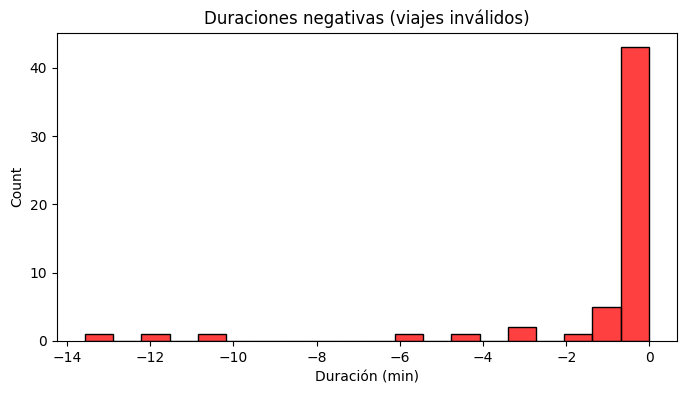


Descripción estadística de duración (sin negativas):


count   2964553.00
mean         15.61
std          34.85
min           0.00
50%          11.63
75%          18.68
90%          28.87
95%          37.93
99%          60.45
max        9455.40
Name: duracion_min, dtype: float64


Umbral p99 de duración: 60.45 min


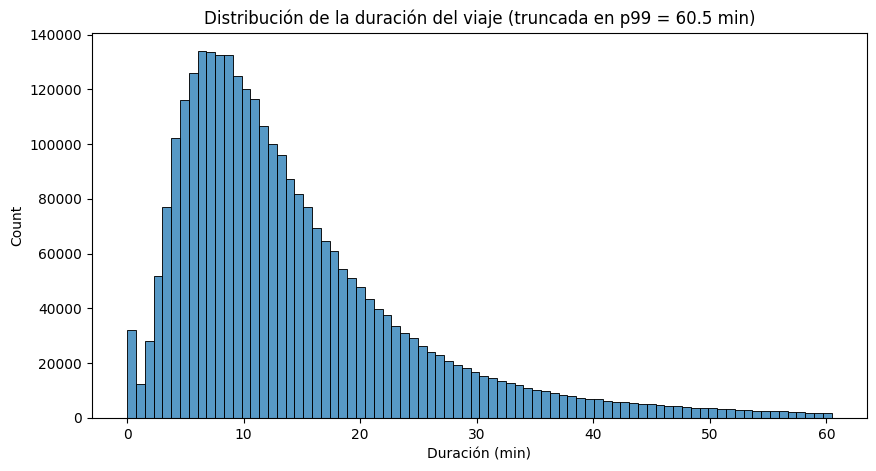

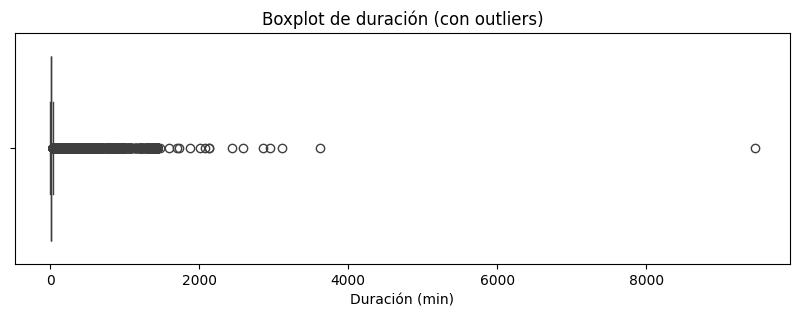

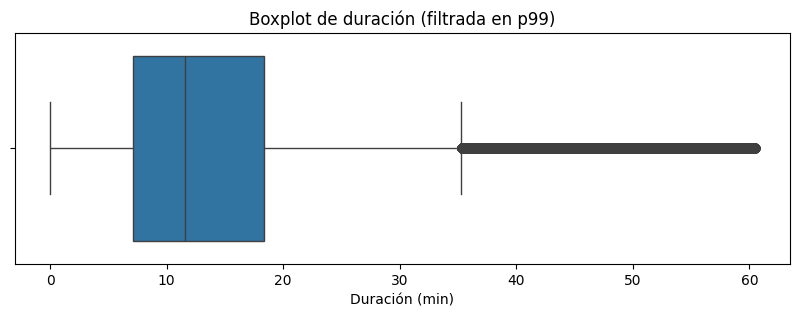

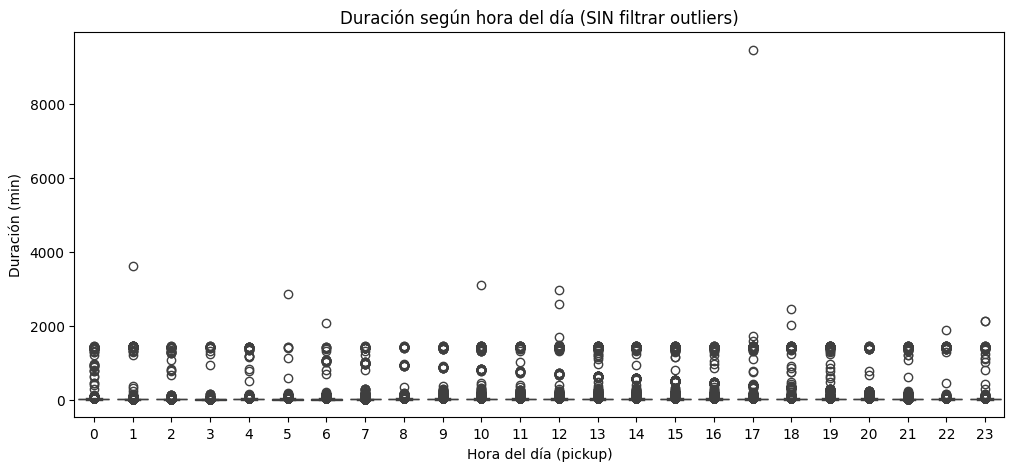

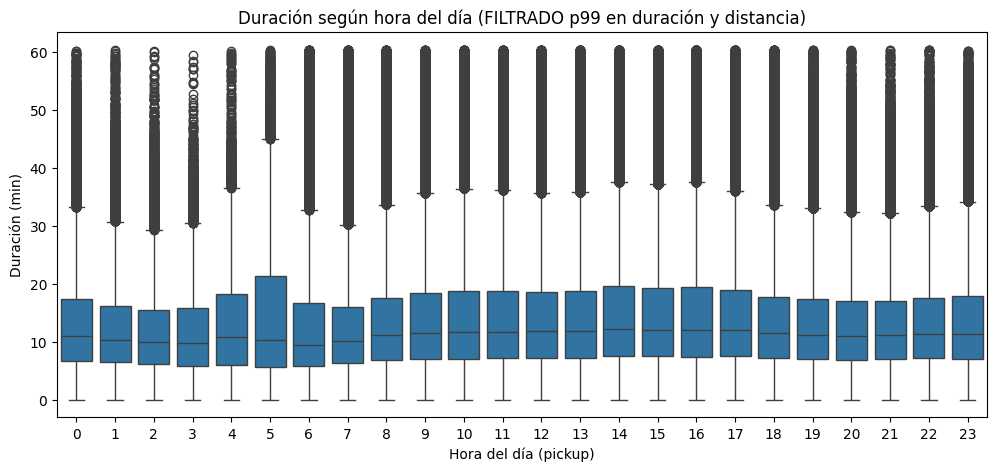

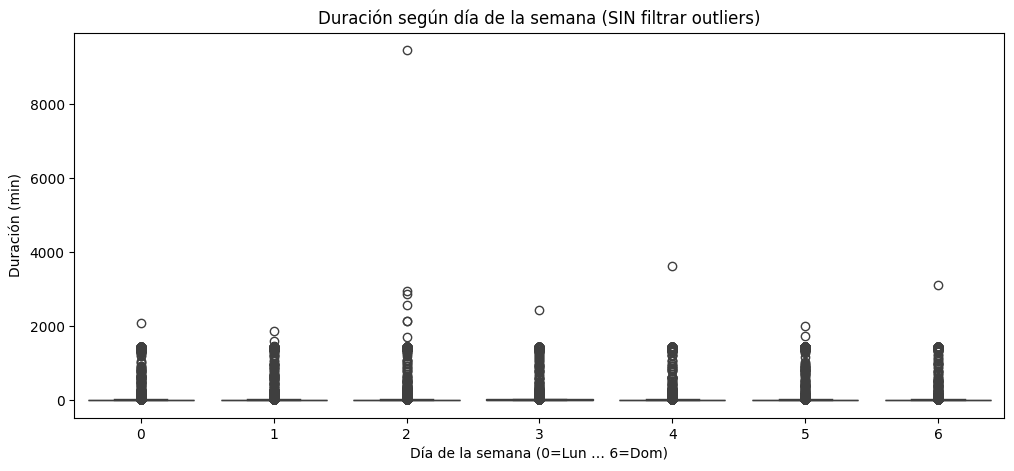

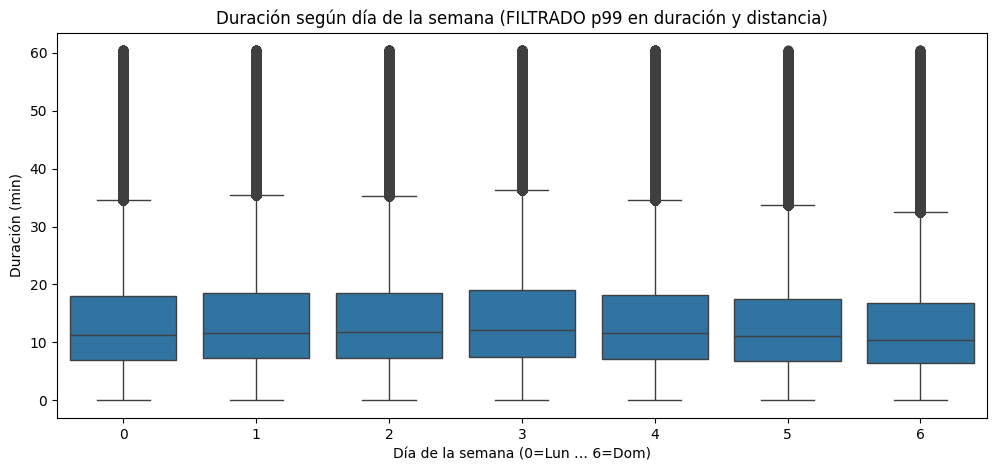

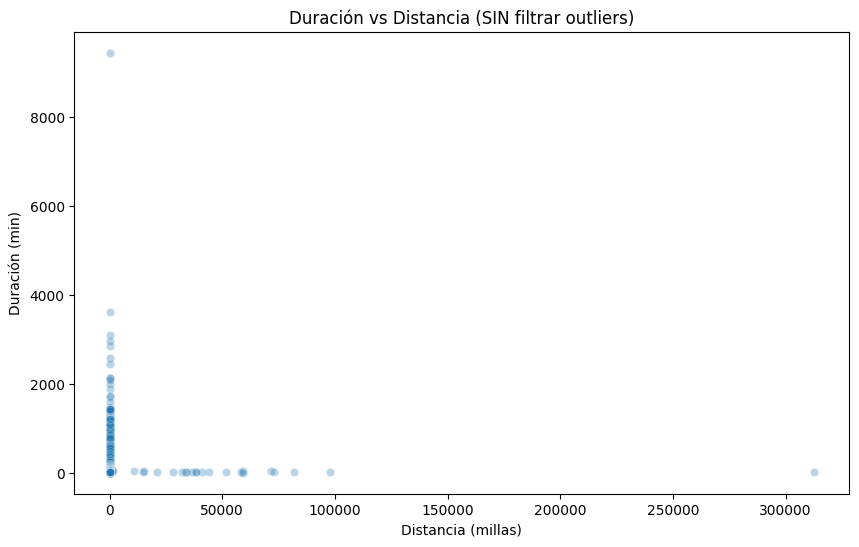

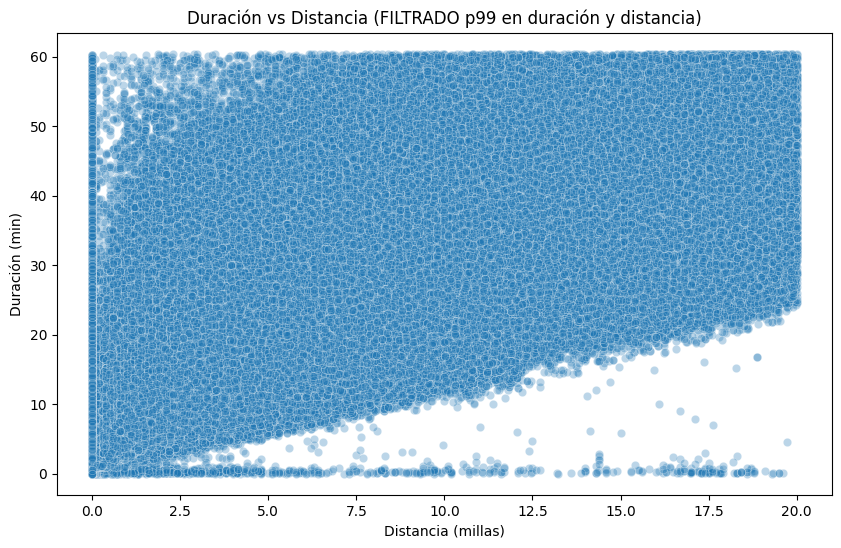

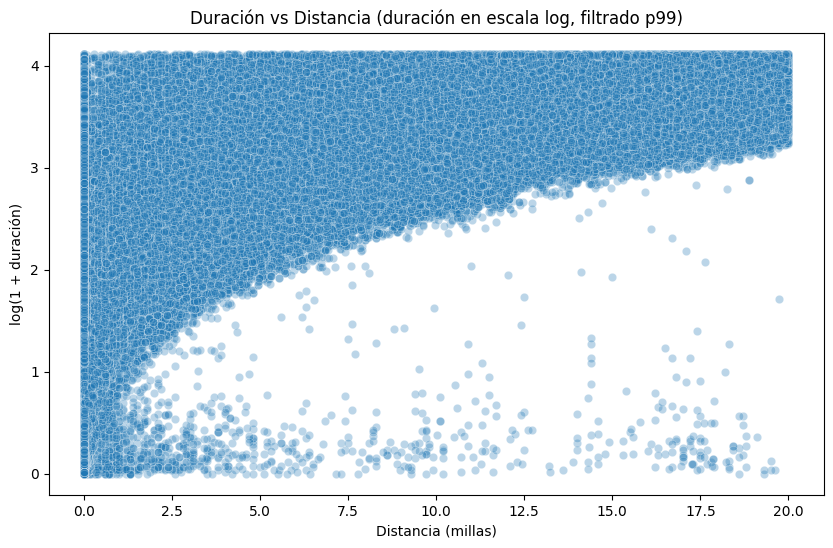


===== FIN DEL ANÁLISIS PICKUP + DROPOFF =====


In [112]:
df_fechas = analisis_pickup_dropoff(
    df_fechas,
    pickup_col="tpep_pickup_datetime",
    dropoff_col="tpep_dropoff_datetime",
    dist_col="trip_distance"
)

## Opciones ML

OP1: Modelo para predecir la duración del viaje (regreción)
El tiempo que durará un viaje dado origen, hora, distancia, etc.
Es exactamente lo que hace Uber/Lyft en su ETA.

OP2: Predicción del monto/precio final del viaje (regresión)


OP3: Predicción de demanda por zona y hora (time series / forecasting)
target: cantidad de viajes en una zona en una hora. Se predice cuántos viajes se pedirán el próximo día/hora/zona
